# Hit Tuning studies

We're using the latest version of `icaruscode`, `v10_06_00_06p03` with all the features included from the work Matteo Vicenzi has been doing on the PMT-overlay and some of the fixes introduced by Micheal Carrigan on the Hit Finder settings



In [1]:
import uproot
import mplhep as hep

# import ultraplot as plot
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd
import xarray as xr

import sqlite3 as sql
import corner


In [2]:
connection = sql.connect('hitTuning_merged_test.db')
data = pd.read_sql('SELECT * FROM runs', connection)

In [3]:
data.keys()

Index(['id', 'jobNum', 'timestamp', 'fcl_filename', 'output_filename',
       'hist_filename', 'roiThreshold_0', 'roiThreshold_1', 'roiThreshold_2',
       'minPulseHeight_0', 'minPulseHeight_1', 'minPulseHeight_2',
       'minPulseSigma_0', 'minPulseSigma_1', 'minPulseSigma_2',
       'LongMaxHits_0', 'LongMaxHits_1', 'LongMaxHits_2', 'LongPulseWidth_0',
       'LongPulseWidth_1', 'LongPulseWidth_2', 'PulseHeightCuts_0',
       'PulseHeightCuts_1', 'PulseHeightCuts_2', 'PulseWidthCuts_0',
       'PulseWidthCuts_1', 'PulseWidthCuts_2', 'PulseRatioCuts_0',
       'PulseRatioCuts_1', 'PulseRatioCuts_2', 'MaxMultiHit', 'Chi2NDF',
       'notes', 'ratio_total', 'ratio_total0', 'ratio_total1', 'ratio_total2',
       'ratio_ele', 'ratio_ele0', 'ratio_ele1', 'ratio_ele2', 'ratio_gamma',
       'ratio_gamma0', 'ratio_gamma1', 'ratio_gamma2', 'ratio_mu', 'ratio_mu0',
       'ratio_mu1', 'ratio_mu2', 'ratio_p', 'ratio_p0', 'ratio_p1', 'ratio_p2',
       'ratio_pi', 'ratio_pi0', 'ratio_pi1', 'rat

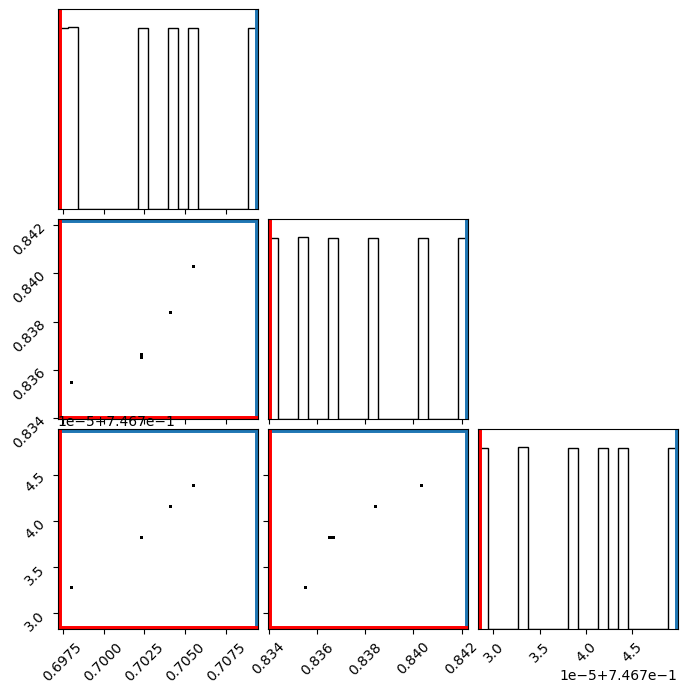

In [12]:
data_electronOnly = data[['ratio_ele0', 'ratio_ele1', 'ratio_ele2']]

data_max = data_electronOnly.sort_values(['ratio_ele0', 'ratio_ele1', 'ratio_ele2'])
max_ele0, max_ele1, max_ele2 = data_max.max()

max_common_ele0, max_common_ele1, max_common_ele2 = data_max.iloc[0]

figure = corner.corner(data_electronOnly.to_numpy(), plot_contours=False, plot_density=False)
corner.overplot_lines(figure, [max_ele0, max_ele1, max_ele2], lw=5)
corner.overplot_lines(figure, [max_common_ele0, max_common_ele1, max_common_ele2], lw=5, color='r')


In [41]:
data[['ratio_ele', 'ratio_ele0', 'ratio_ele1', 'ratio_ele2']]

,ratio_ele,ratio_ele0,ratio_ele1,ratio_ele2
0,0.759800,0.704042,0.838419,0.746742
1,0.756085,0.697187,0.833961,0.746728
2,0.756788,0.697982,0.835519,0.746733
3,0.756085,0.697187,0.833961,0.746728
4,0.759800,0.704042,0.838419,0.746742
...,...,...,...,...
2875,0.756085,0.697187,0.833961,0.746728
2876,0.760854,0.705500,0.840309,0.746744
2877,0.760854,0.705500,0.840309,0.746744
2878,0.758645,0.702314,0.836655,0.746738


In [10]:

data_max

,ratio_ele0,ratio_ele1,ratio_ele2
1,0.697187,0.833961,0.746728
3,0.697187,0.833961,0.746728
7,0.697187,0.833961,0.746728
12,0.697187,0.833961,0.746728
13,0.697187,0.833961,0.746728
...,...,...,...
2860,0.709429,0.842245,0.746750
2862,0.709429,0.842245,0.746750
2863,0.709429,0.842245,0.746750
2868,0.709429,0.842245,0.746750


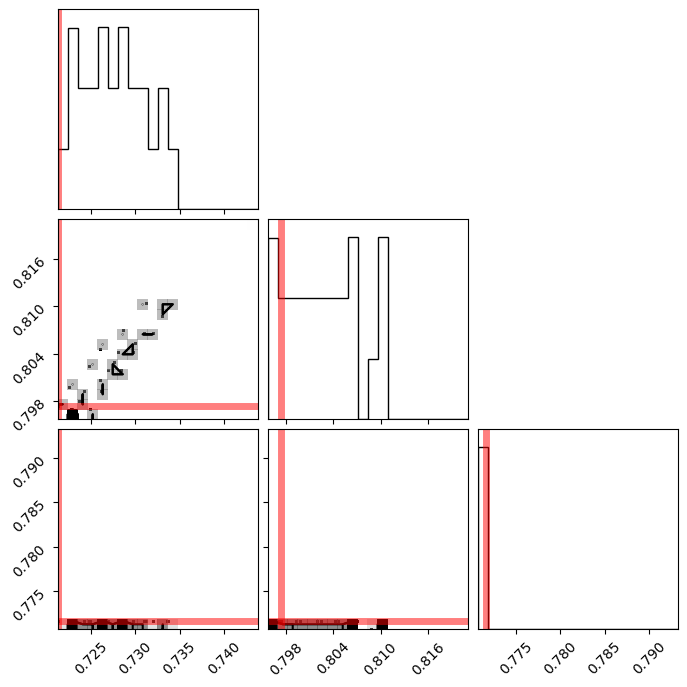

In [22]:
data_electronOnly = data[['ratio_p0', 'ratio_p1', 'ratio_p2']]

data_max = data_electronOnly.sort_values(['ratio_p0', 'ratio_p2', 'ratio_p1', ])
max_0, max_1, max_2 = data_max.max()

max_common_0, max_common_1, max_common_2 = data_max.iloc[0]

figure = corner.corner(data_electronOnly.to_numpy())
# corner.overplot_lines(figure, [max_0, max_1, max_2 ], lw=5, alpha=0.5)
corner.overplot_lines(figure, [max_common_0, max_common_1, max_common_2], lw=5, alpha=0.5, color='r')

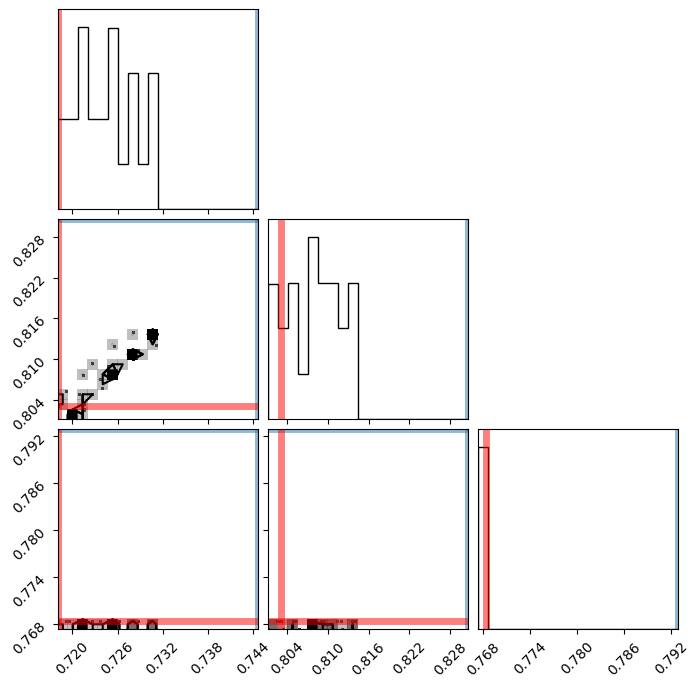

In [23]:
data_electronOnly = data[['ratio_mu0', 'ratio_mu1', 'ratio_mu2']]

data_max = data_electronOnly.sort_values(['ratio_mu0', 'ratio_mu1', 'ratio_mu2'])
max_ele0, max_ele1, max_ele2 = data_max.max()

max_common_ele0, max_common_ele1, max_common_ele2 = data_max.iloc[0]

figure = corner.corner(data_electronOnly.to_numpy())
corner.overplot_lines(figure, [max_ele0, max_ele1, max_ele2], lw=5, alpha=0.5)
corner.overplot_lines(figure, [max_common_ele0, max_common_ele1, max_common_ele2], lw=5, alpha=0.5, color='r')

In [44]:
def plot_corner_byPlane(plane=''):
    max_all = data[f'ratio_total{plane}'].max()
    dataToPlot = data[[f'ratio_ele{plane}', f'ratio_gamma{plane}', f'ratio_mu{plane}', f'ratio_p{plane}', f'ratio_pi{plane}', ]]

    emax, gmax, mumax, pmax, pimax = dataToPlot.max()

    print(emax, gmax, mumax, pmax, pimax)
    
    fig = corner.corner(dataToPlot.to_numpy(), labels=['e', '$\\gamma$', '$\\mu$', 'p', '$\\pi$'], bins=10)
    corner.overplot_lines(fig, [emax, gmax, mumax, pmax, pimax], color='r', lw=5)
    corner.overplot_lines(fig, [max_all]*5)

0.7628617286682129 0.7665247321128845 0.7880255579948425 0.7850344181060791 0.7513871192932129


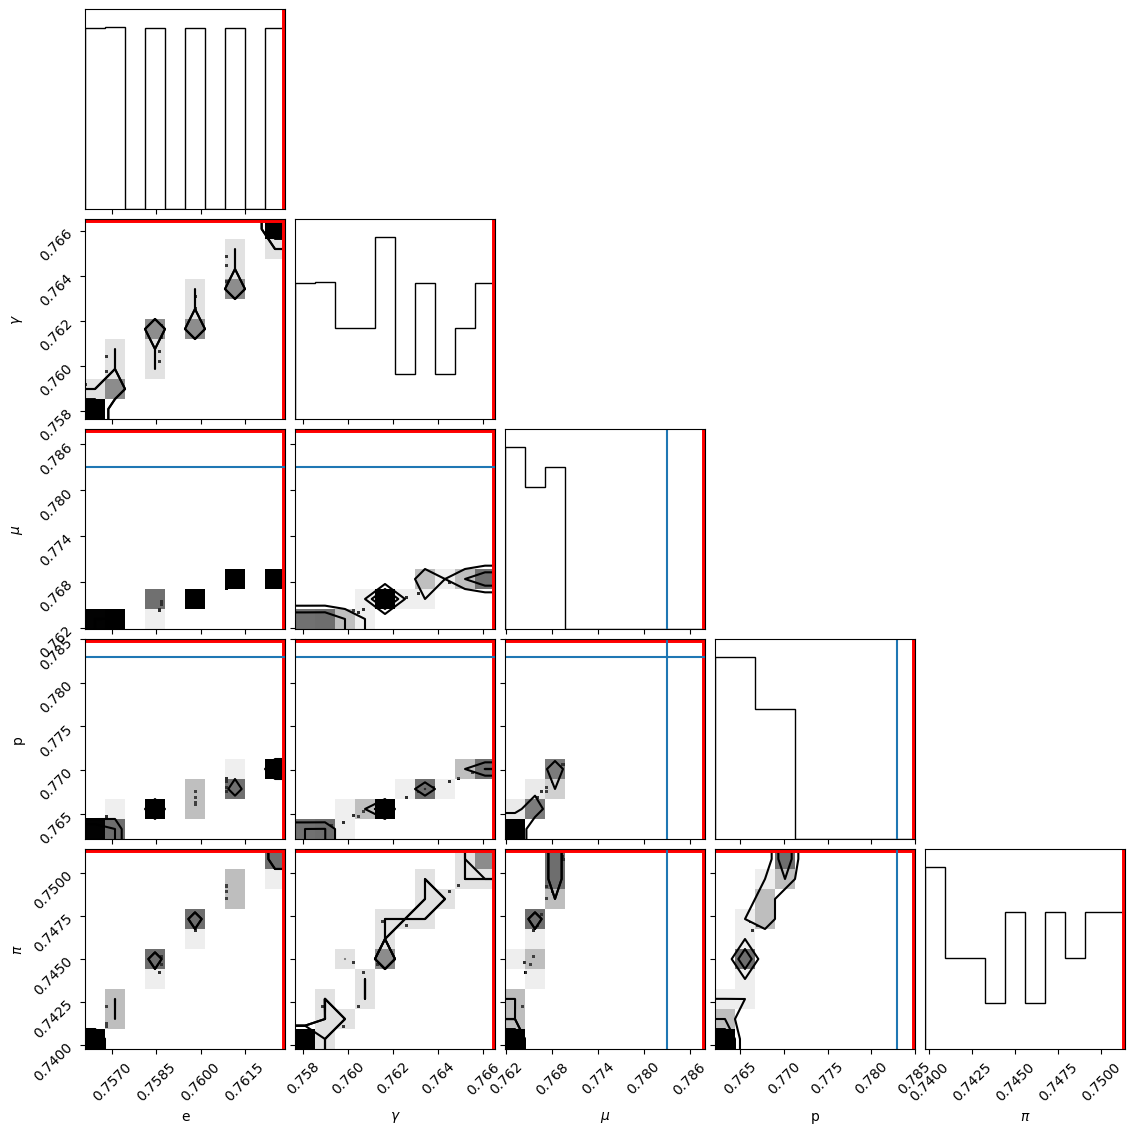

In [45]:
plot_corner_byPlane()

0.7094287872314453 0.7330619692802429 0.744664192199707 0.7438199520111084 0.7041745185852051


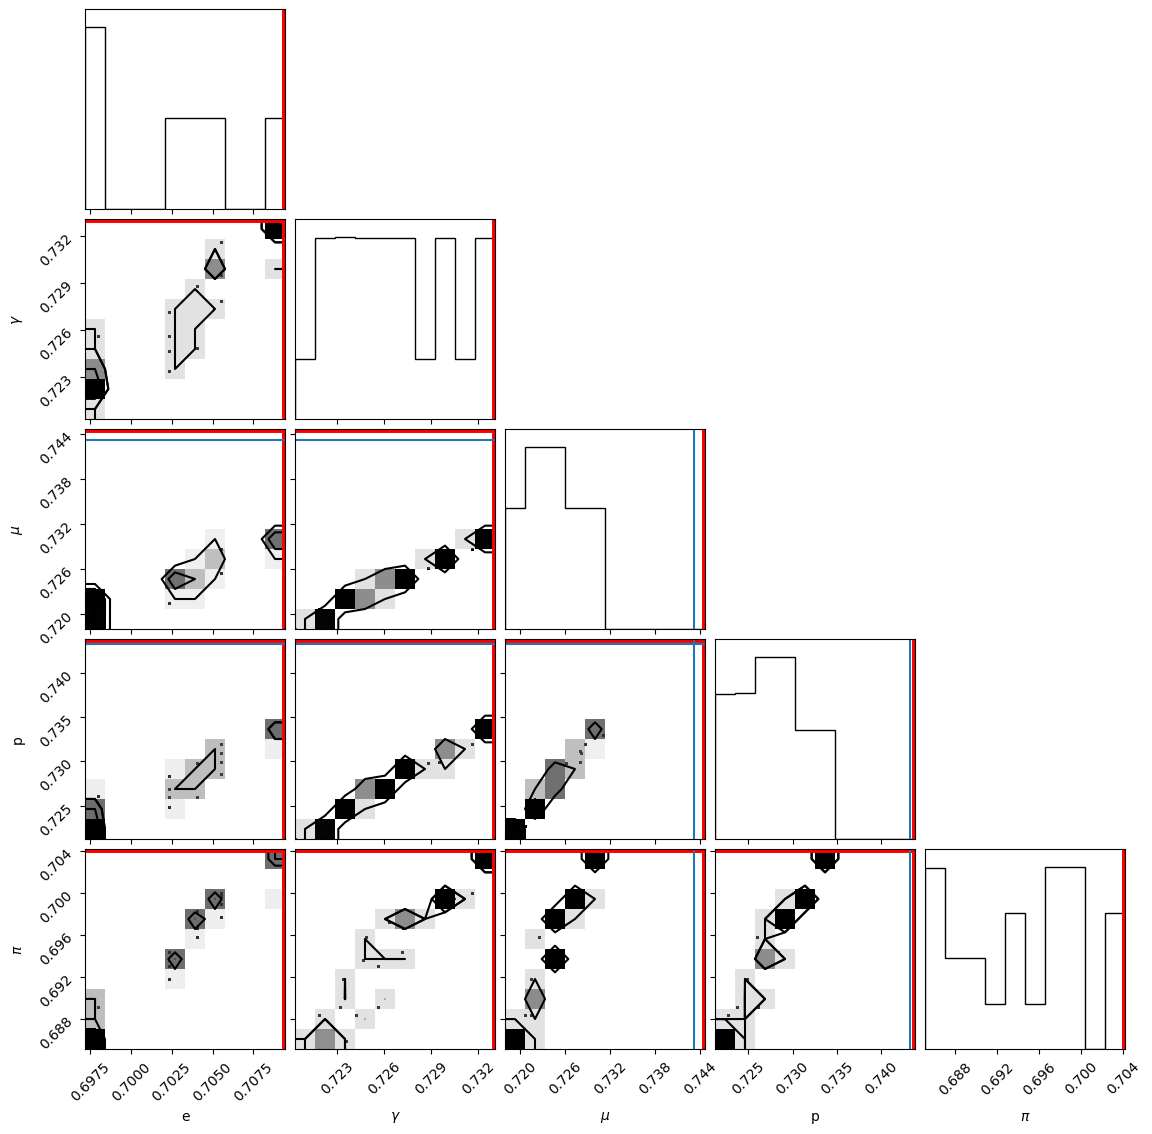

In [46]:
plot_corner_byPlane(0)

0.8422446250915527 0.8049690127372742 0.8305667042732239 0.8210634589195251 0.8309879899024963


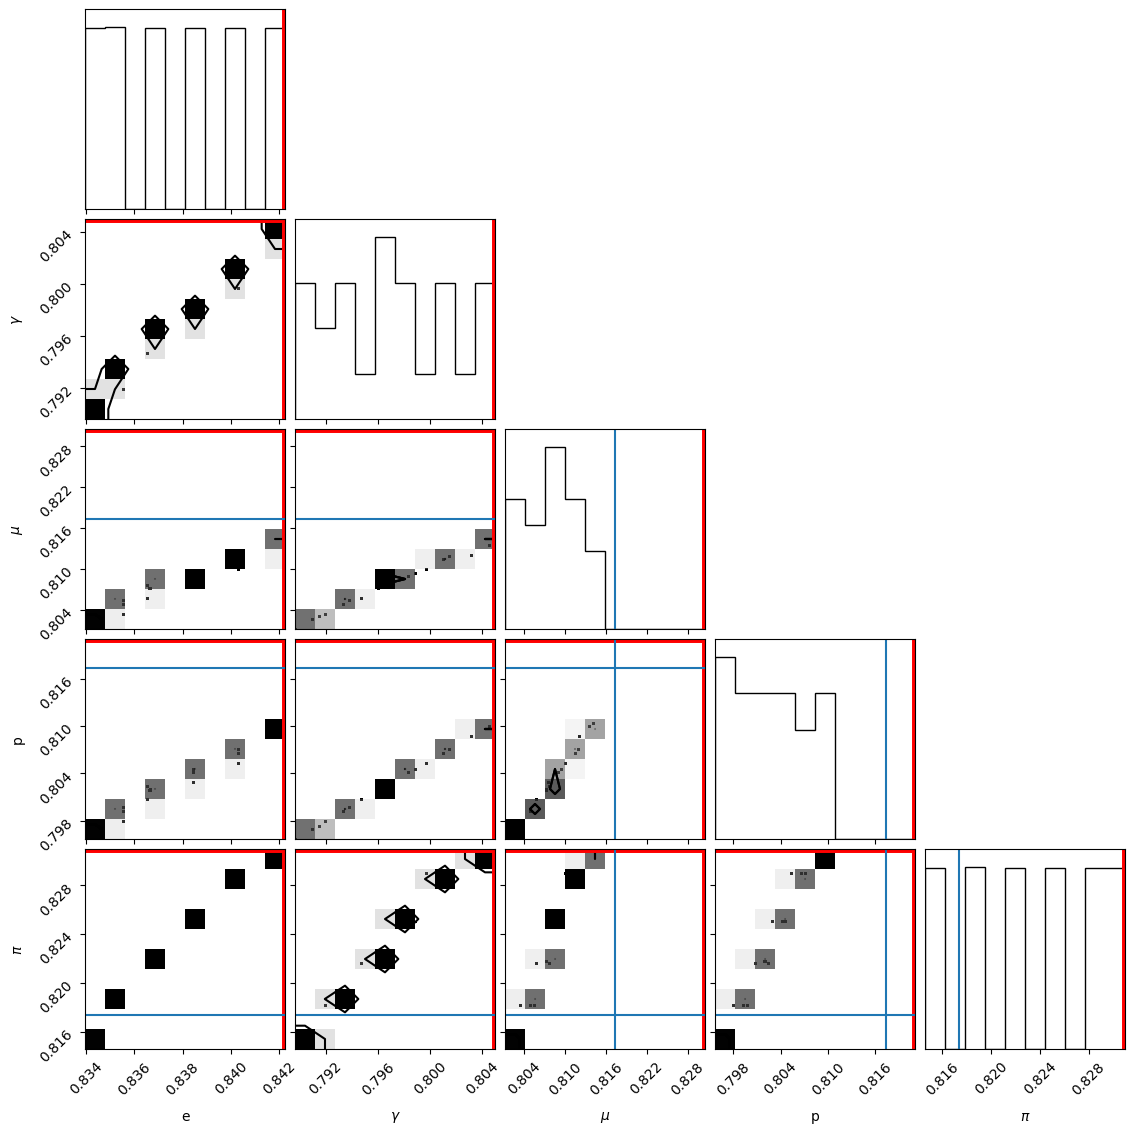

In [47]:
plot_corner_byPlane(1)

0.7467499375343323 0.7652602195739746 0.7928732633590698 0.7932560443878174 0.7303574085235596


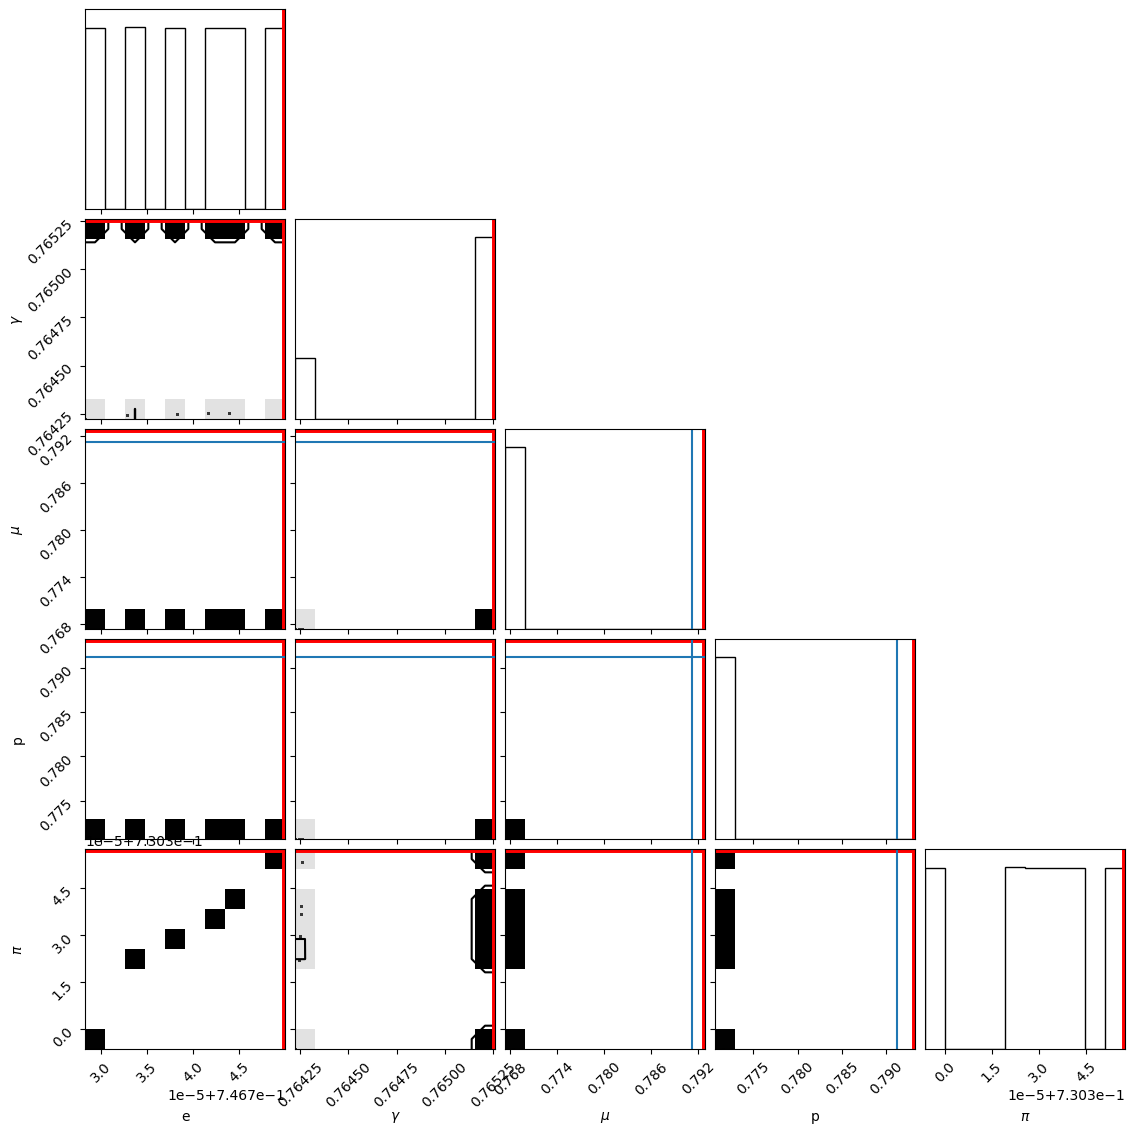

In [48]:
plot_corner_byPlane(2)

In [61]:
def plot_corner_byPlane(plane='', compareTo='ratio_total{}'):
    dataToPlot = data[[
        # f'ratio_ele{plane}', f'ratio_gamma{plane}', f'ratio_mu{plane}', f'ratio_p{plane}', f'ratio_pi{plane}', 
        'ratio_total{}'.format(plane), 
        f'roiThreshold_{plane}',
        # f'minPulseHeight_{plane}',
        # f'minPulseSigma_{plane}',
        f'LongMaxHits_{plane}',
        f'LongPulseWidth_{plane}',
        f'PulseHeightCuts_{plane}',
        # f'PulseWidthCuts_{plane}',
        # f'PulseRatioCuts_{plane}',
        'MaxMultiHit',
        'Chi2NDF',
    ]]
    
    fig = corner.corner(dataToPlot.to_numpy(), labels=[
        'Hit energy/IDE', 
        'ROI trh', 
        # 'MP height', 
        # 'MP $\\sigma$', 
        'LongMaxHits', 
        'LongPulseWidth', 
        'PulseHeightCuts', 
        # 'PulseWidthCuts', 
        # 'PulseRatioCuts', 
        'MaxMultiHit', 
        'Chi2NDF'
    ], bins=[15, 6, 4, 3, 2, 4, 5])
    return fig

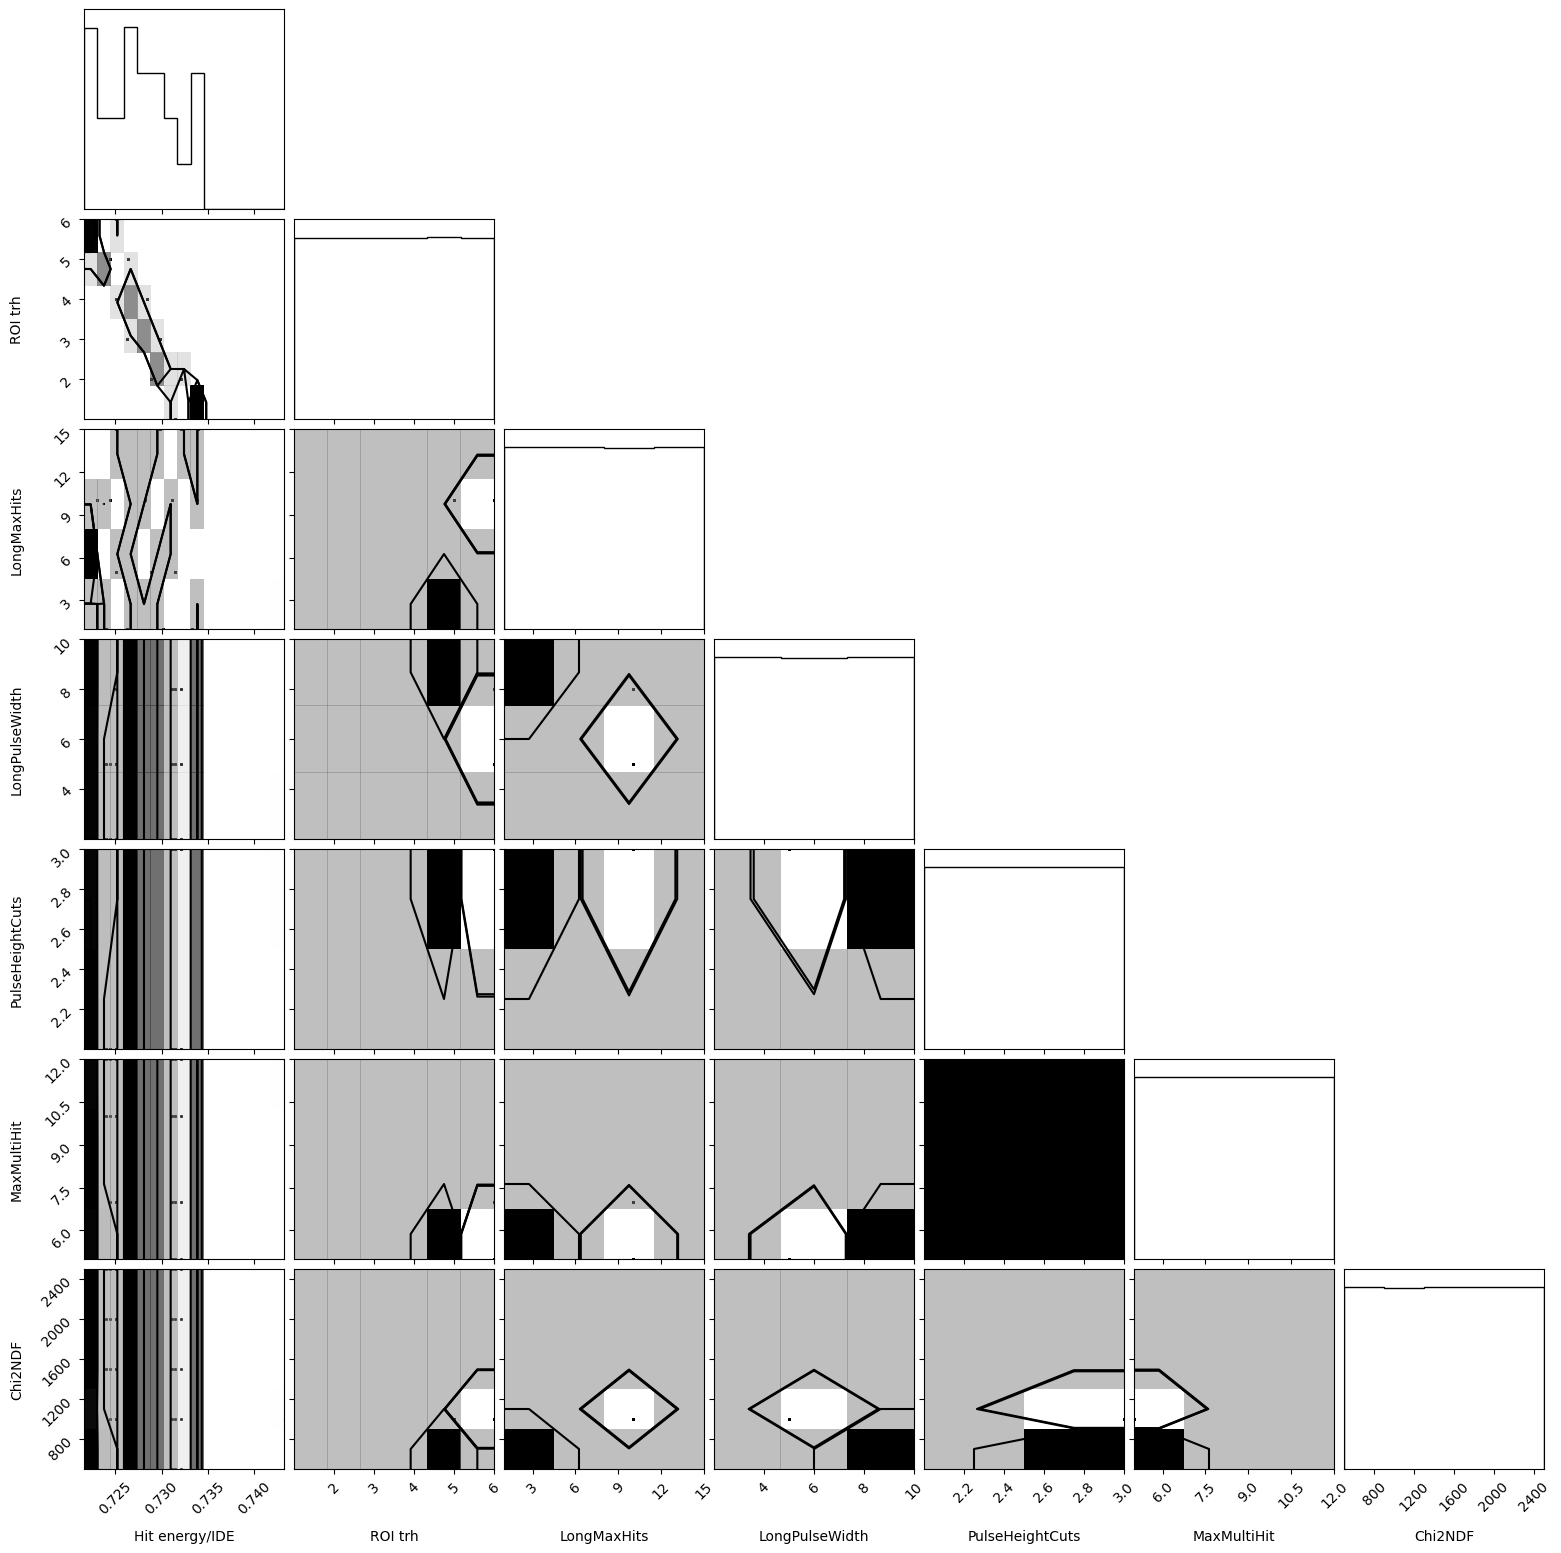

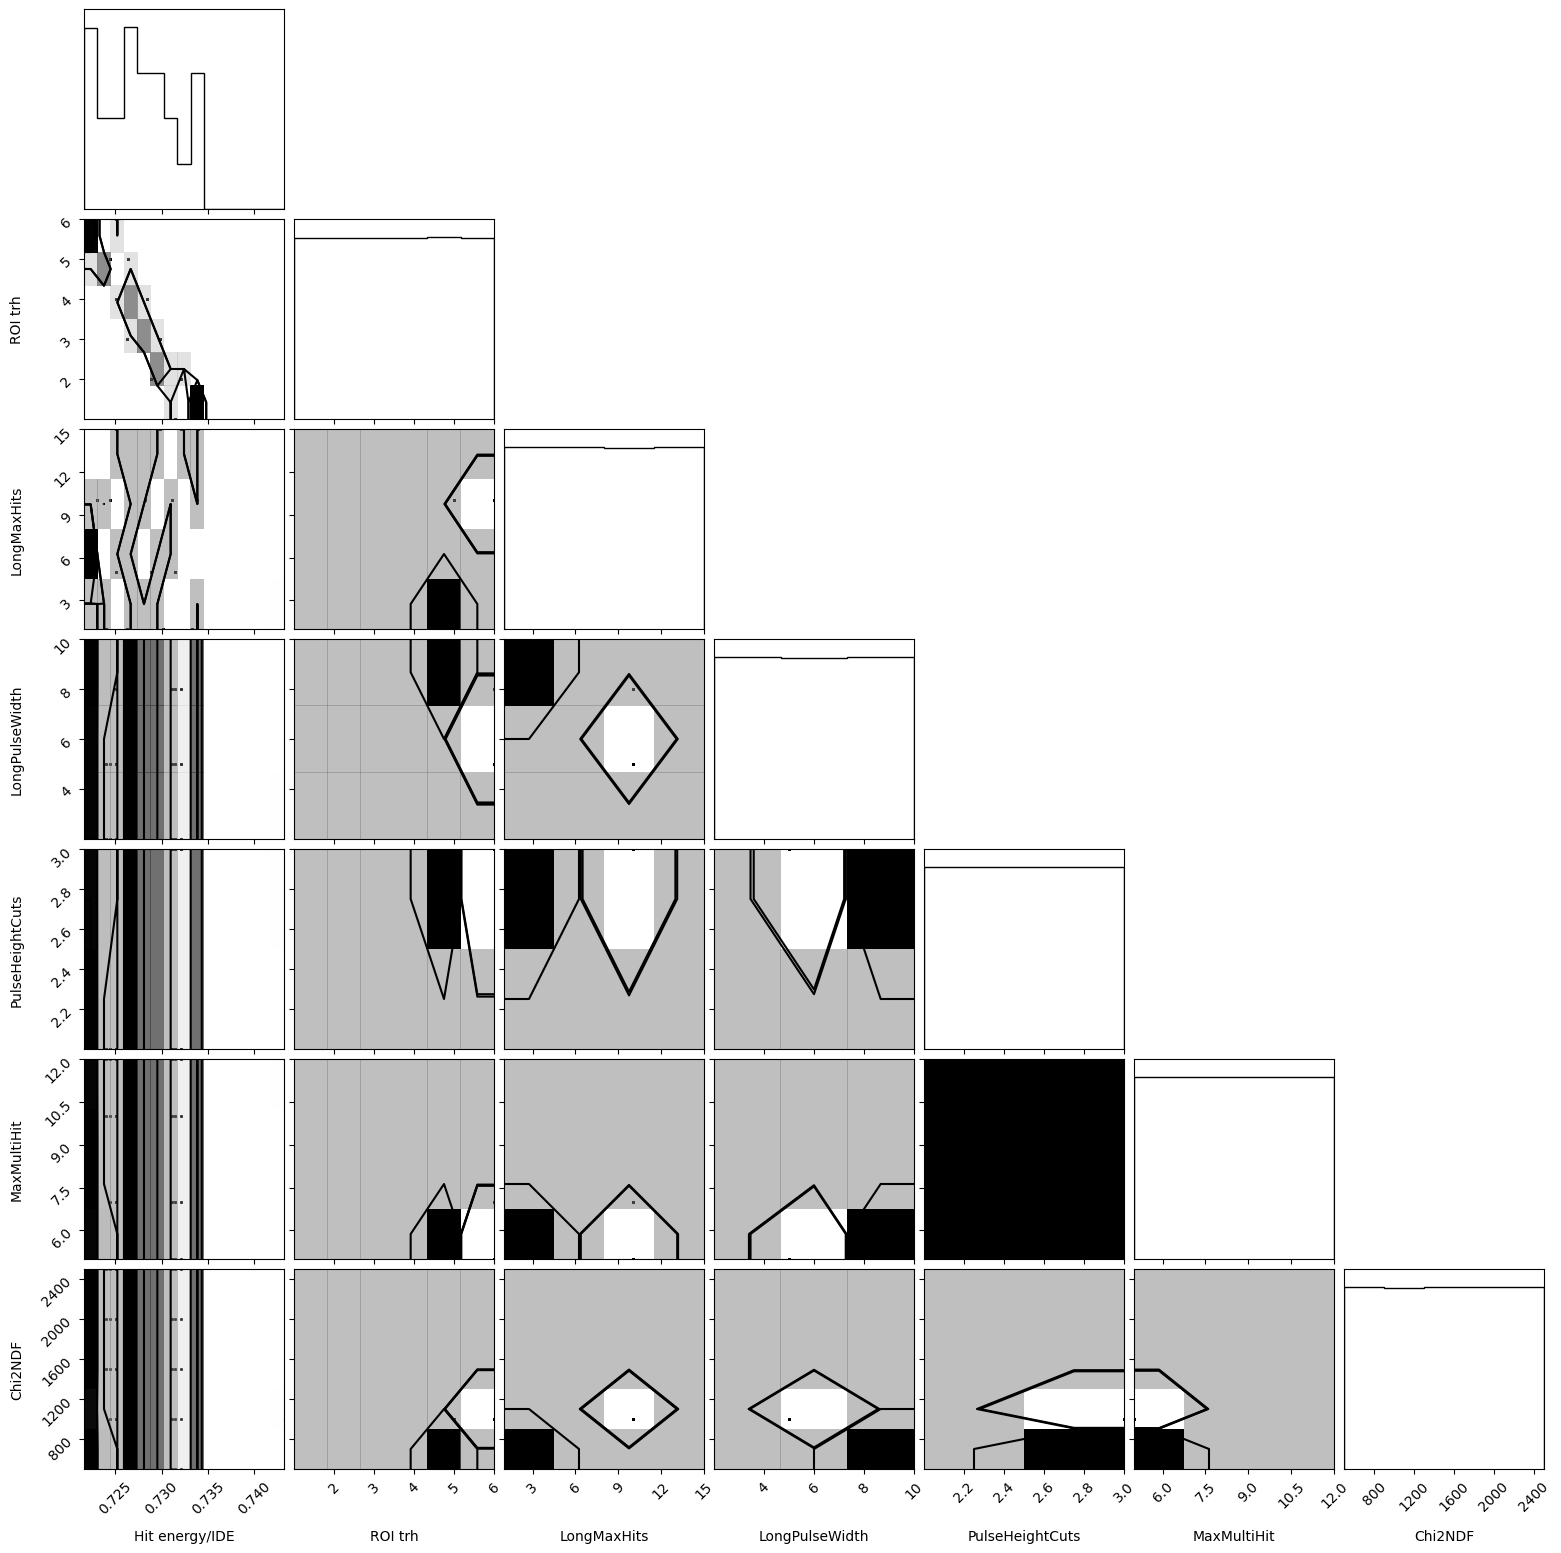

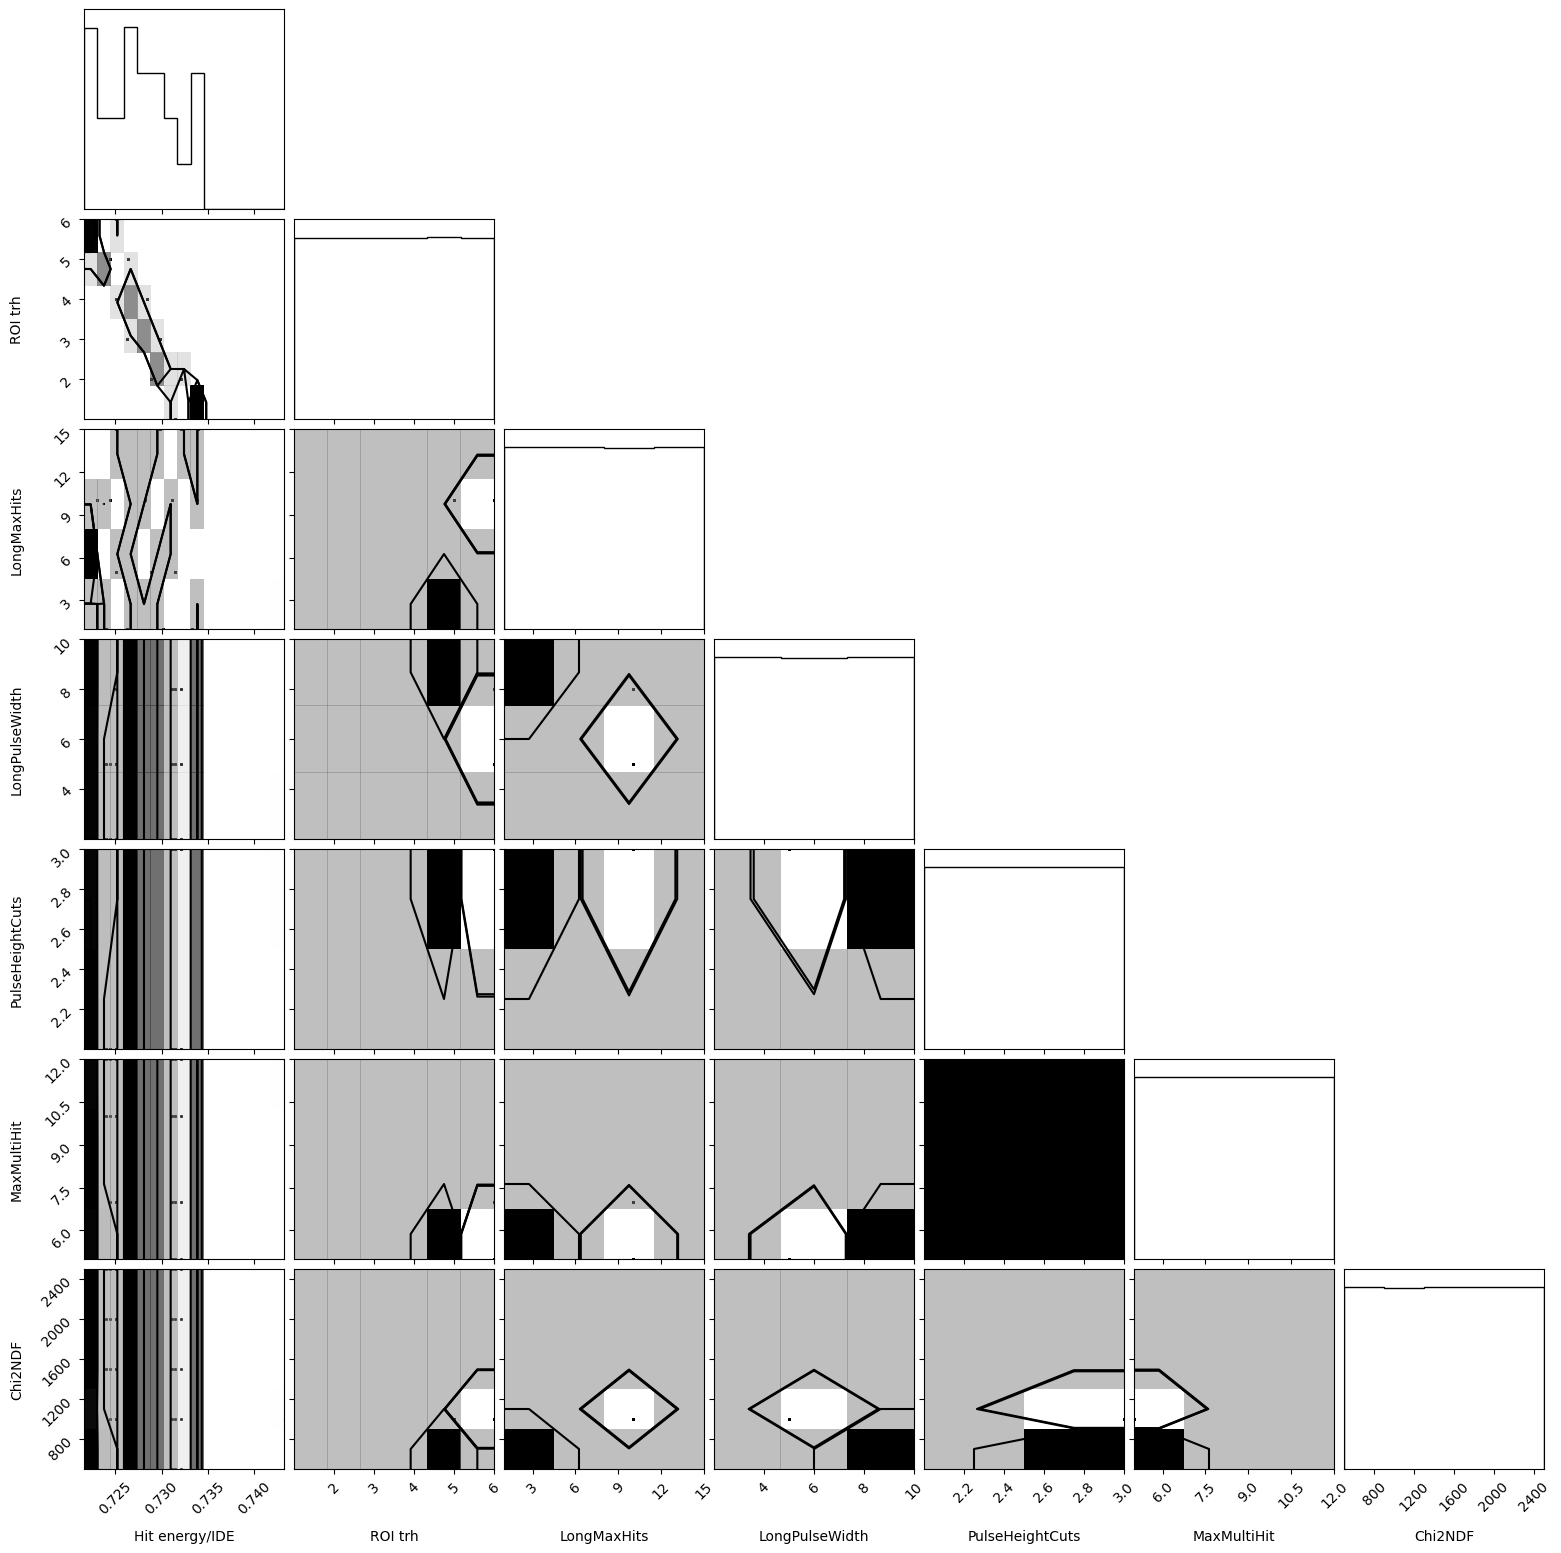

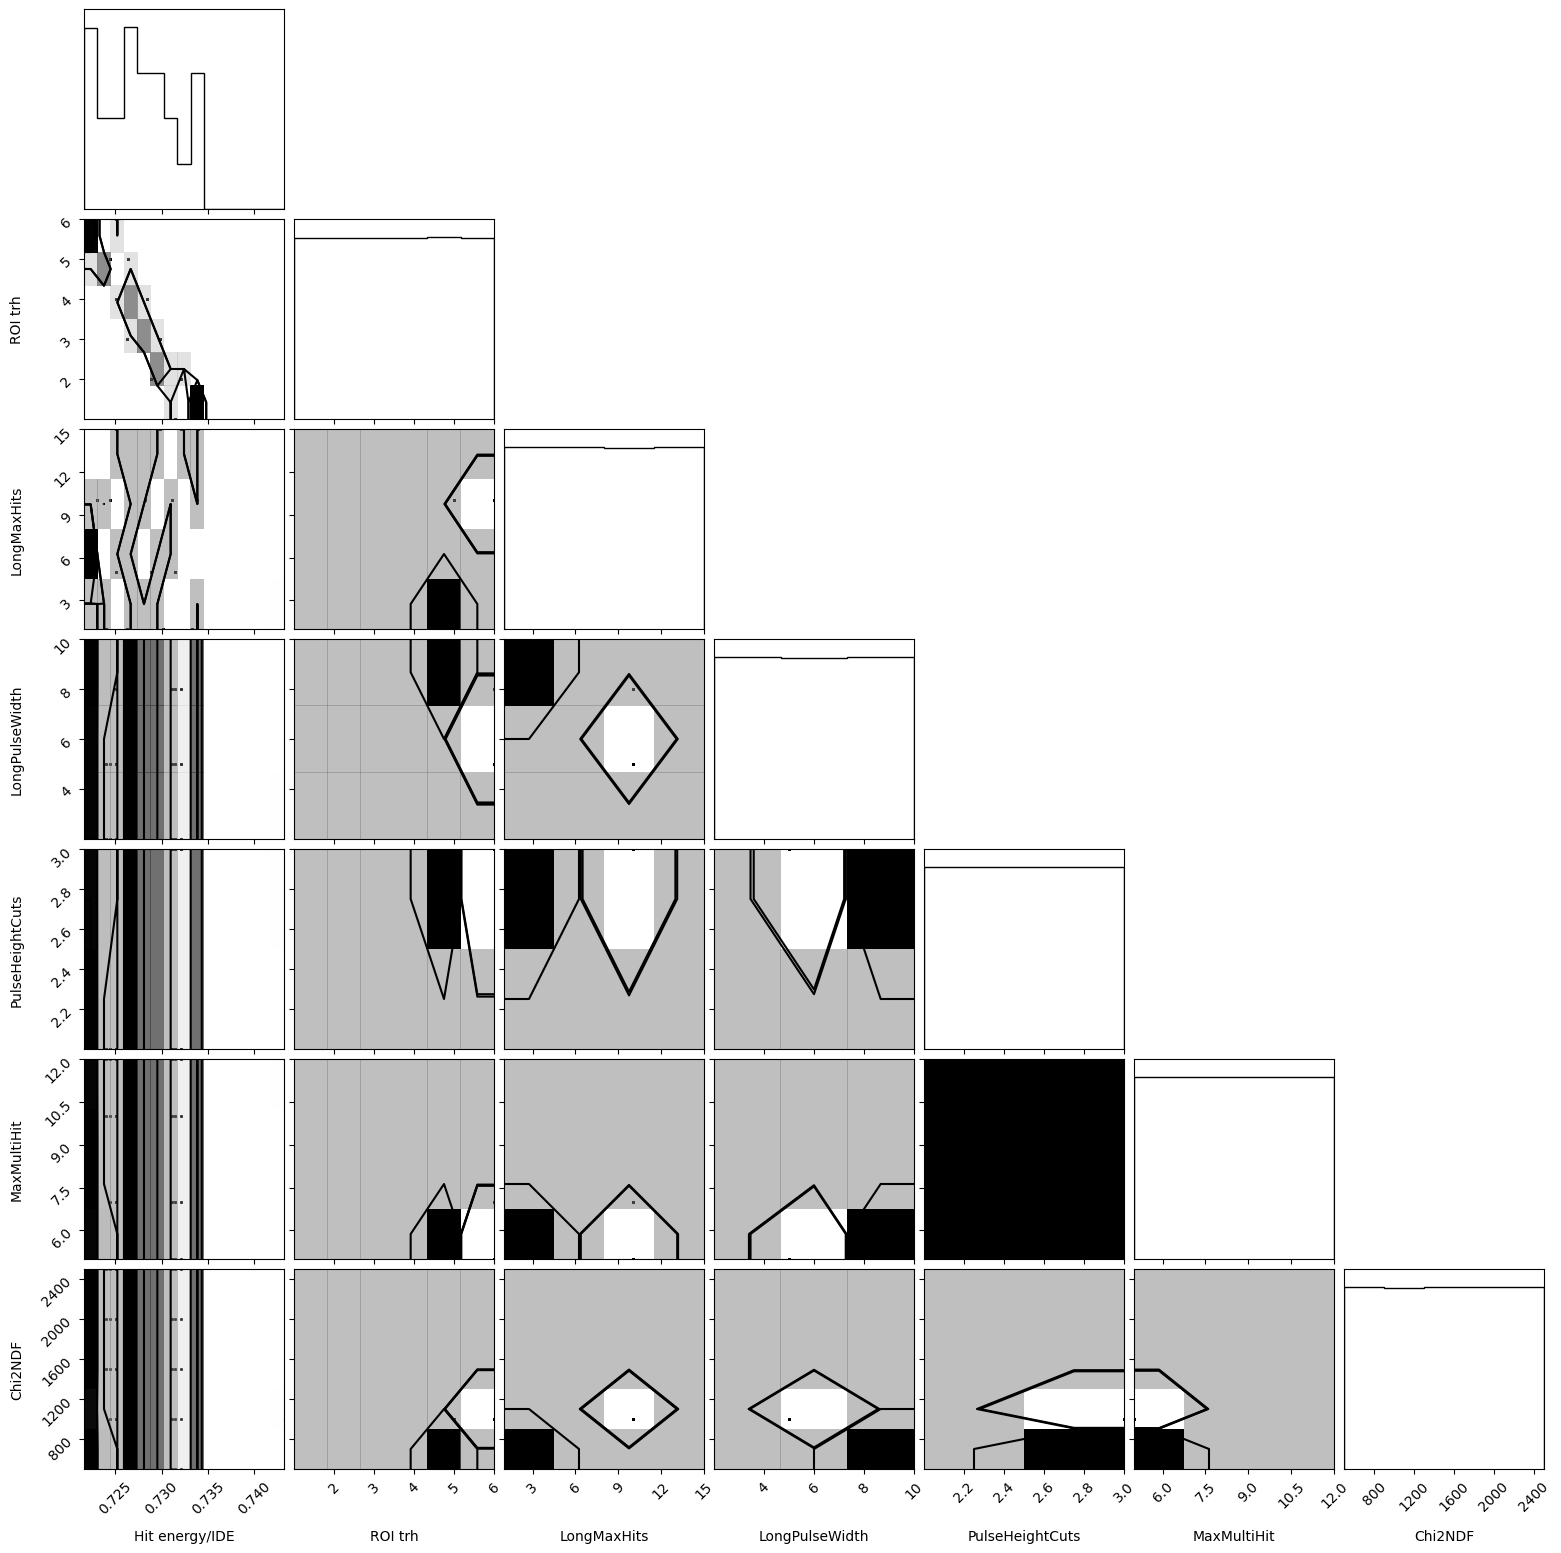

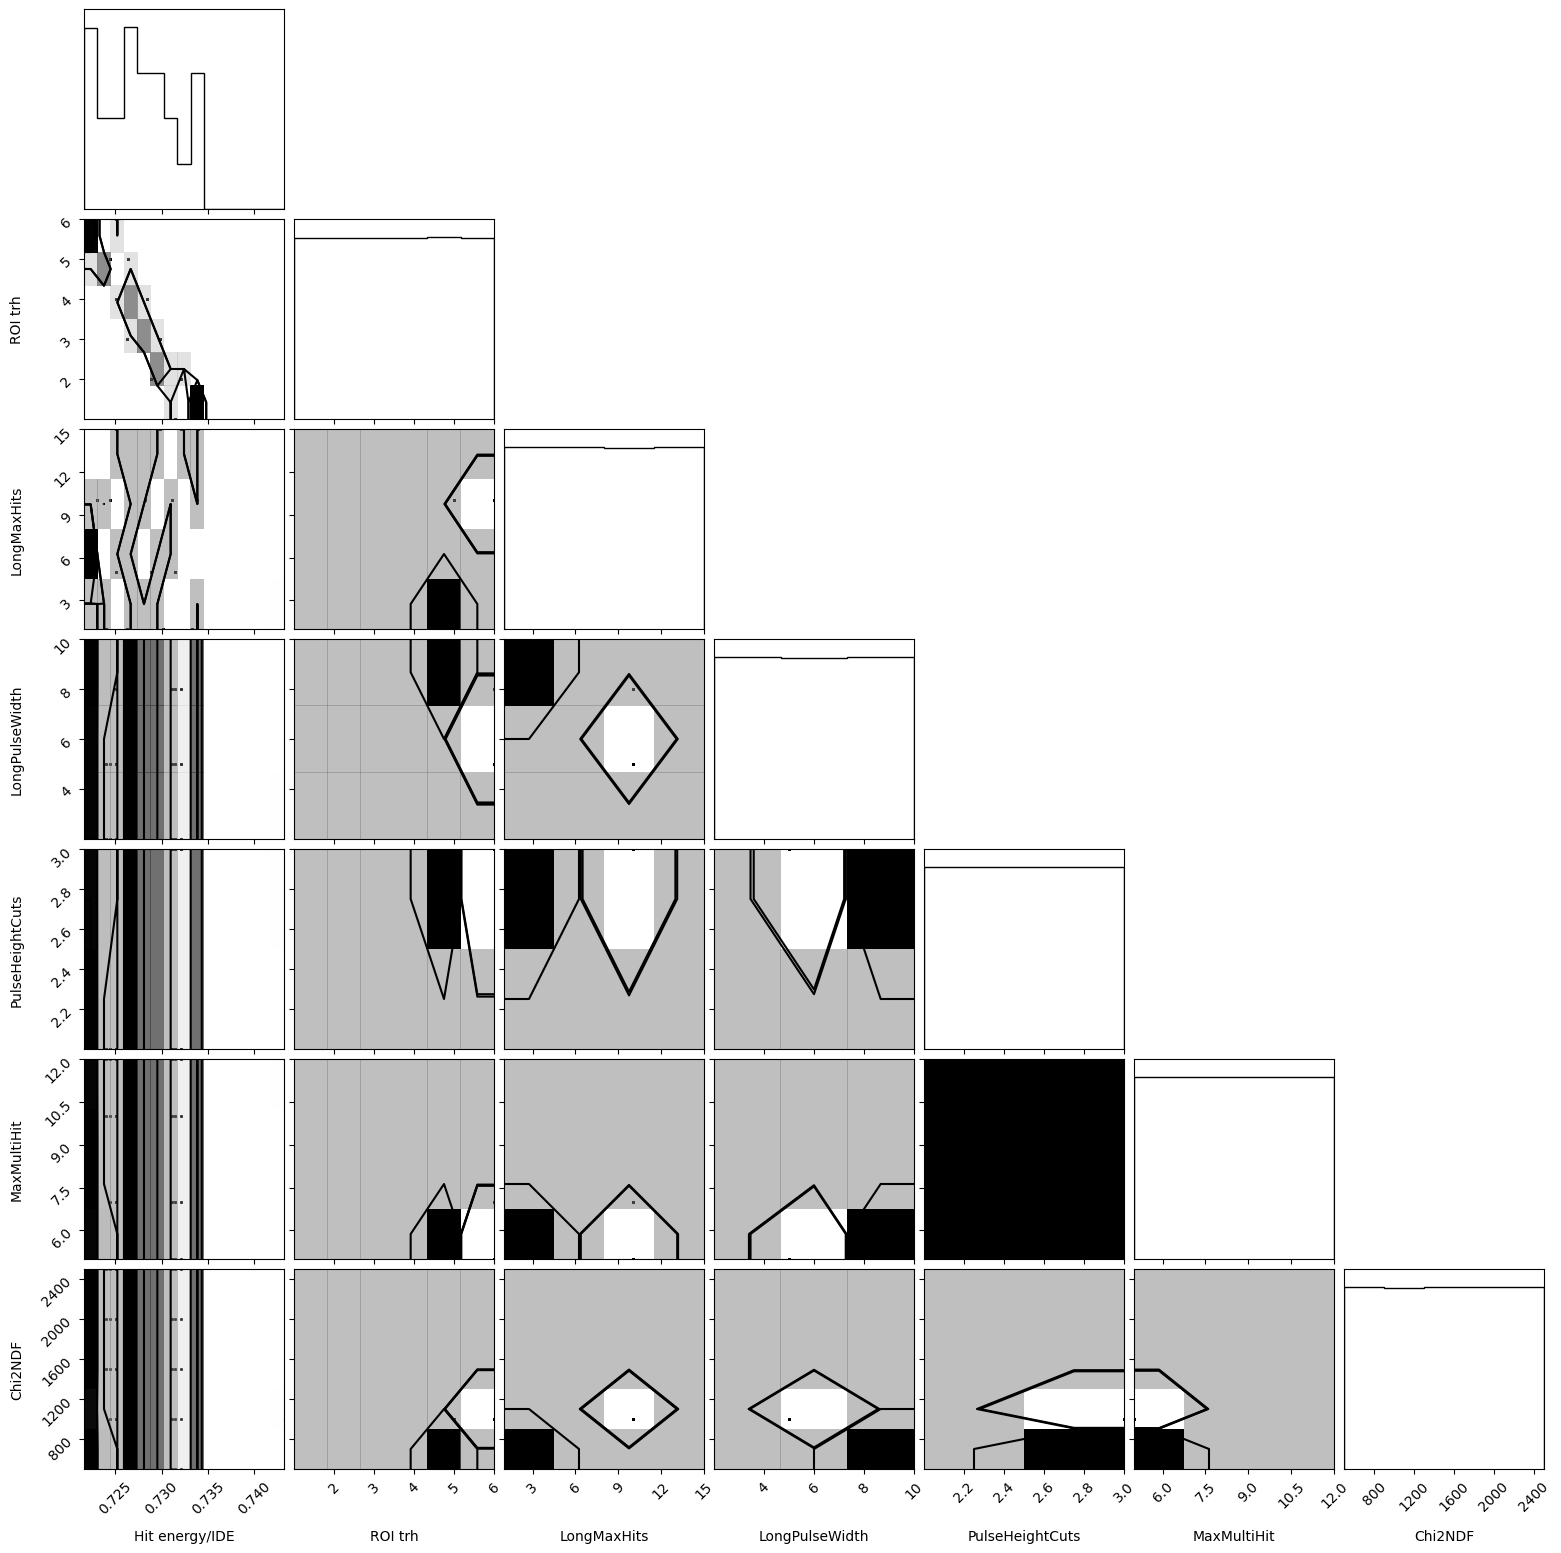

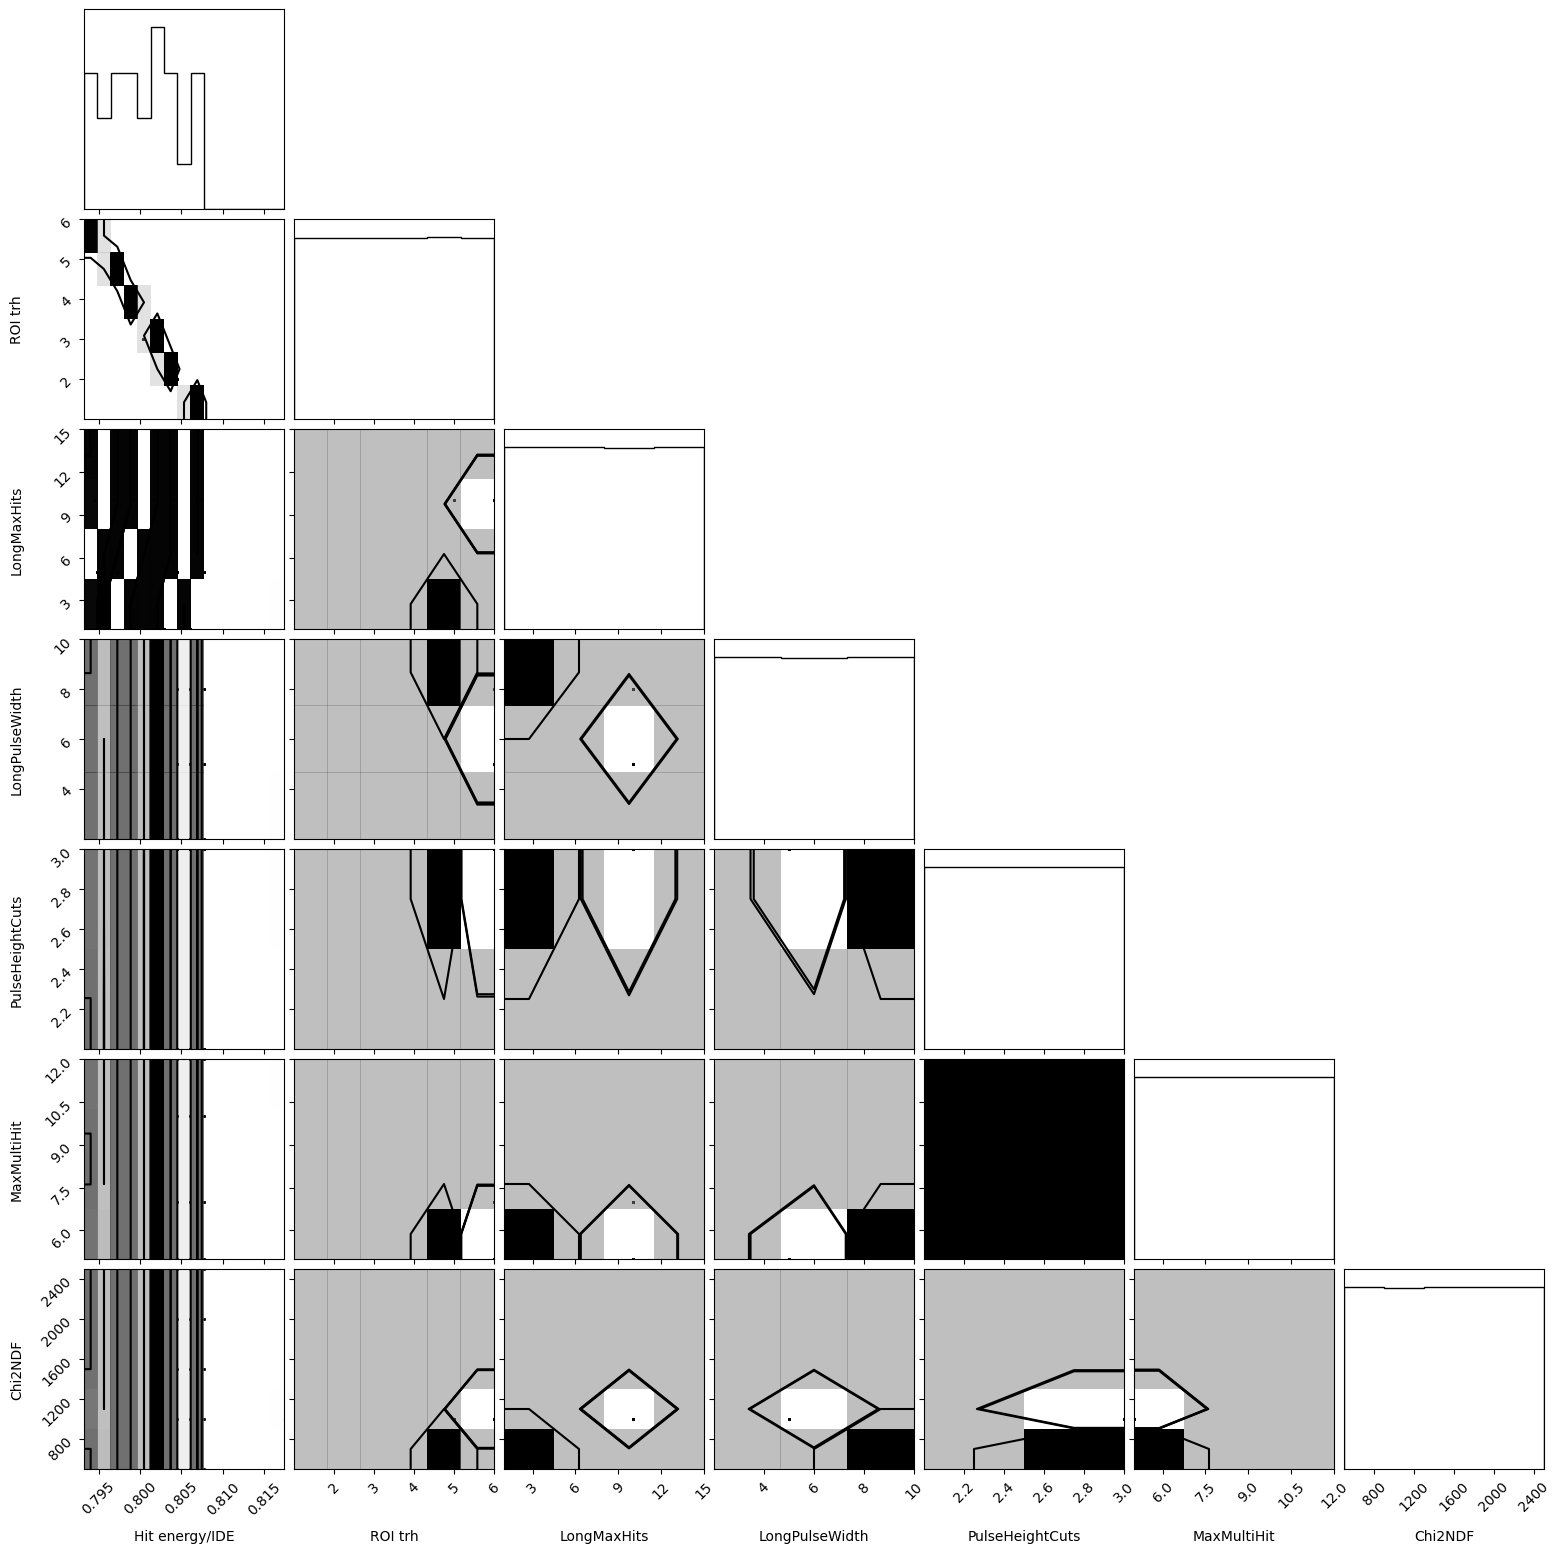

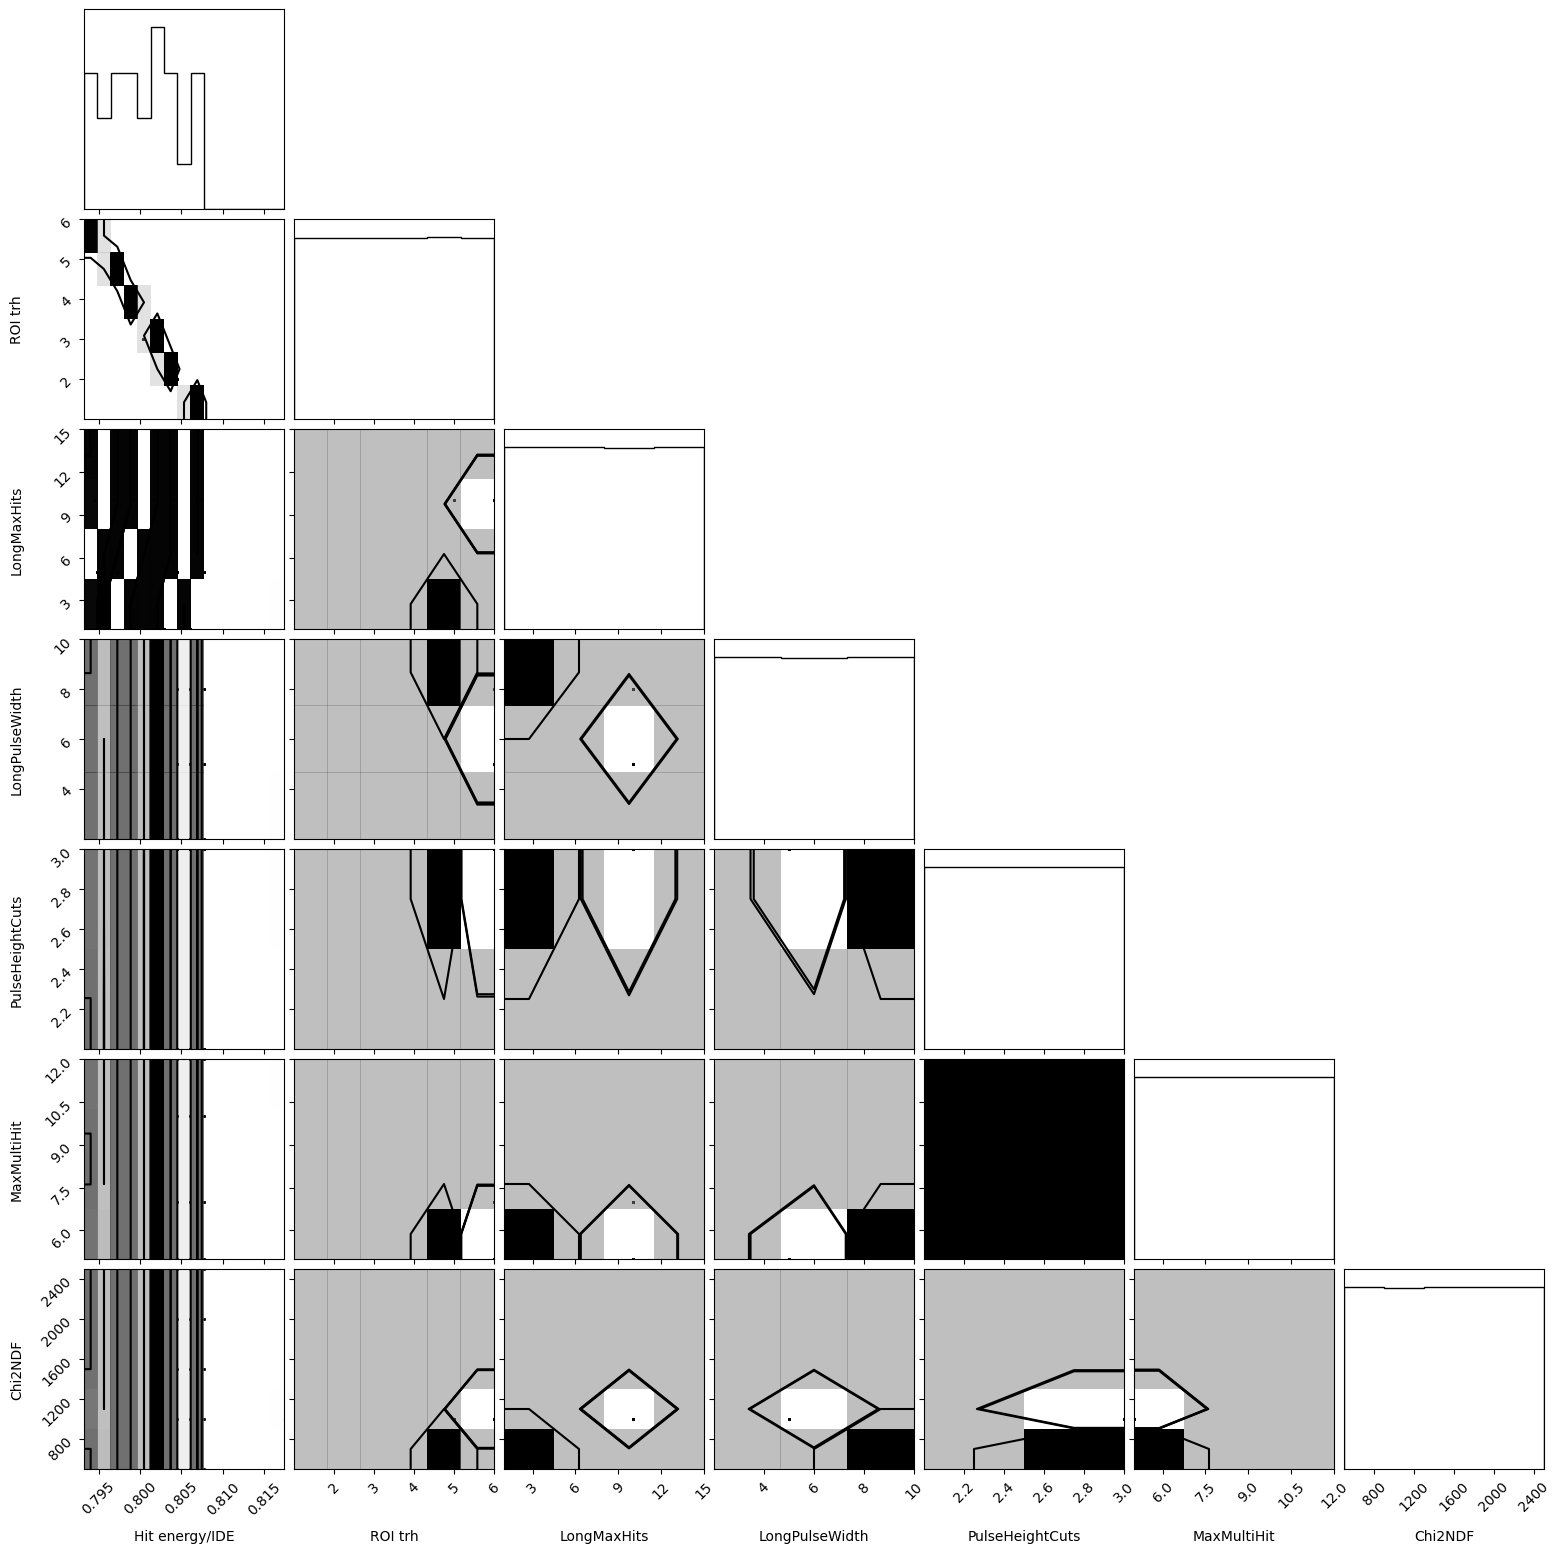

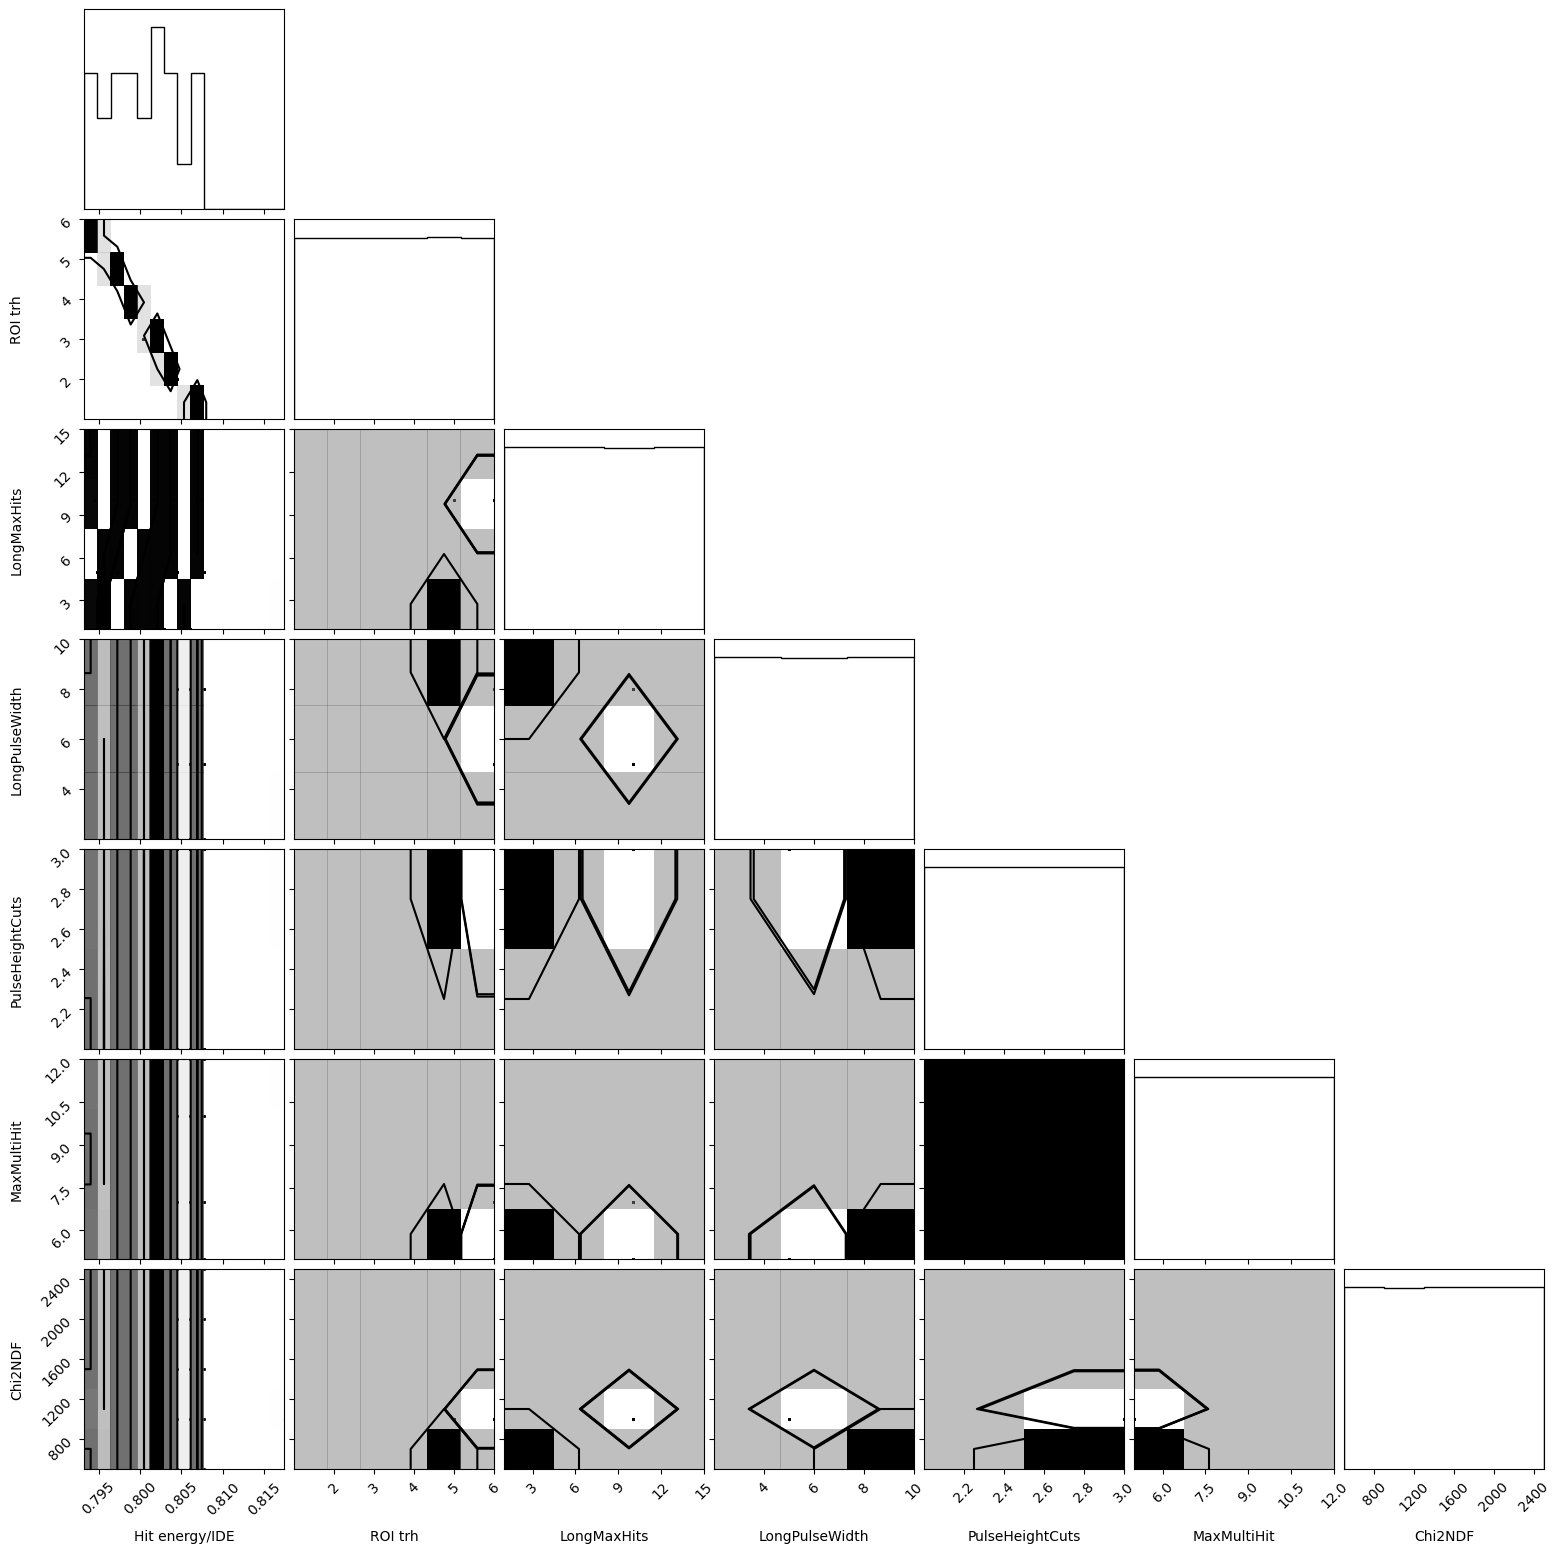

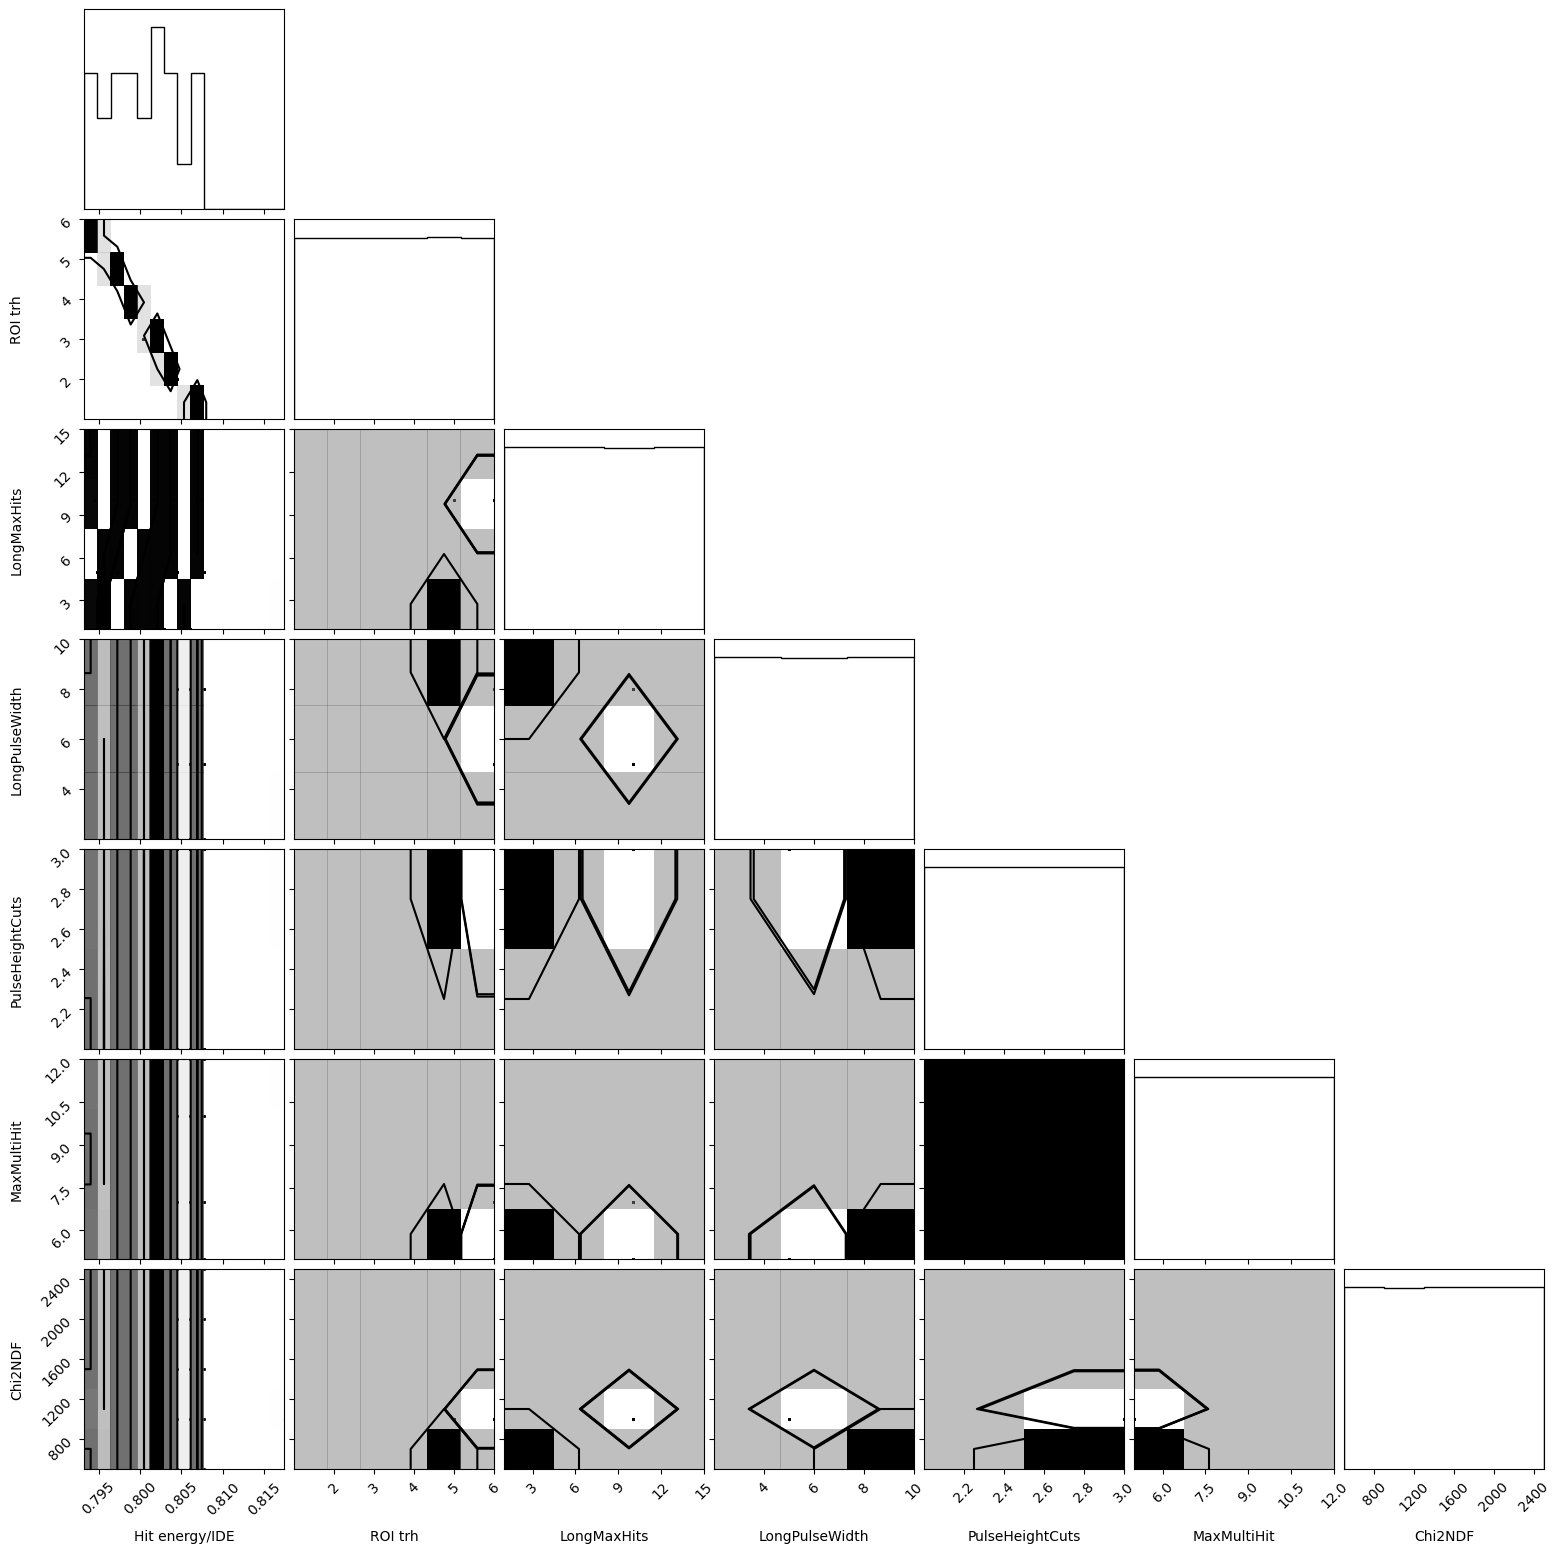

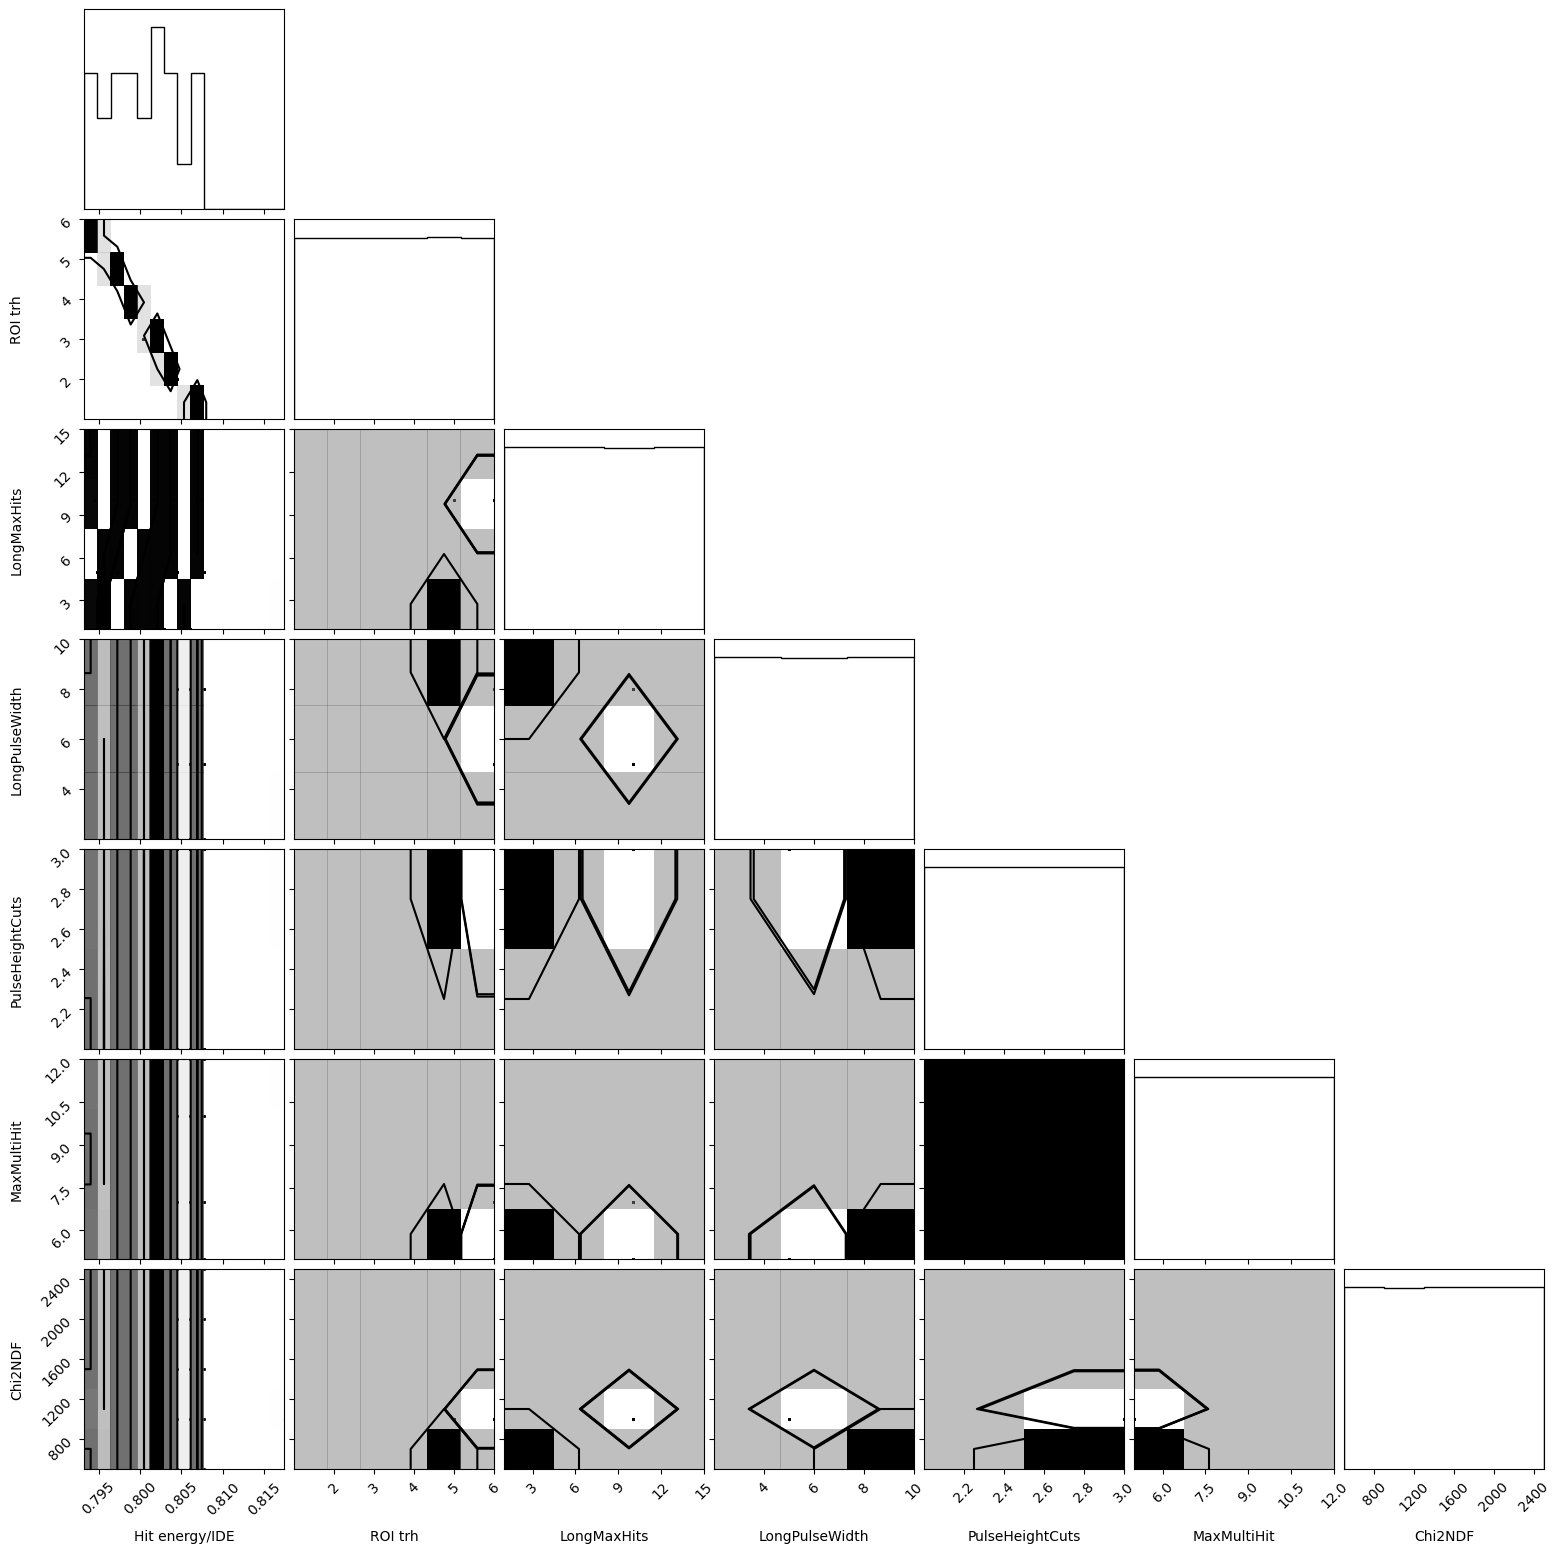

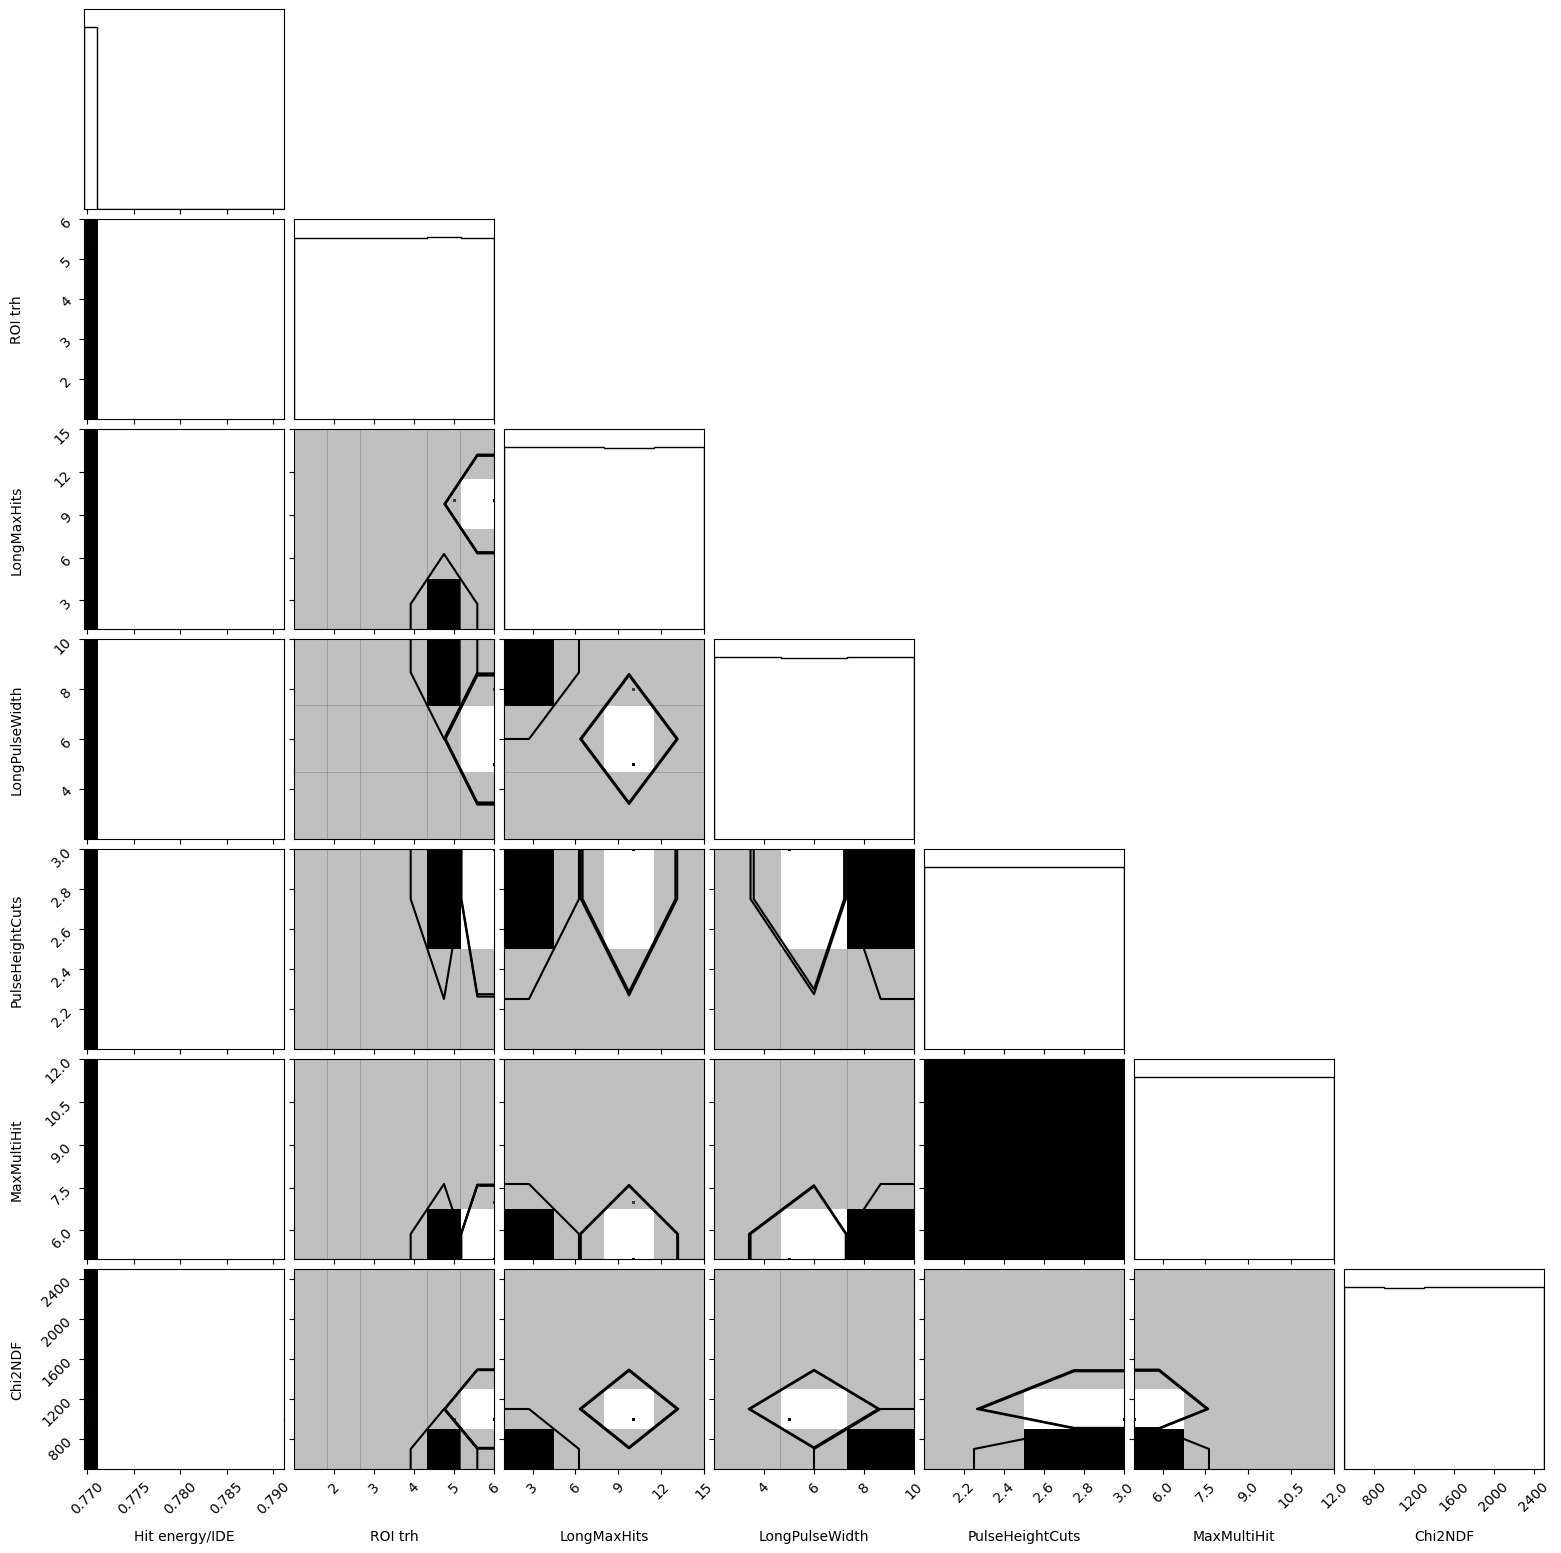

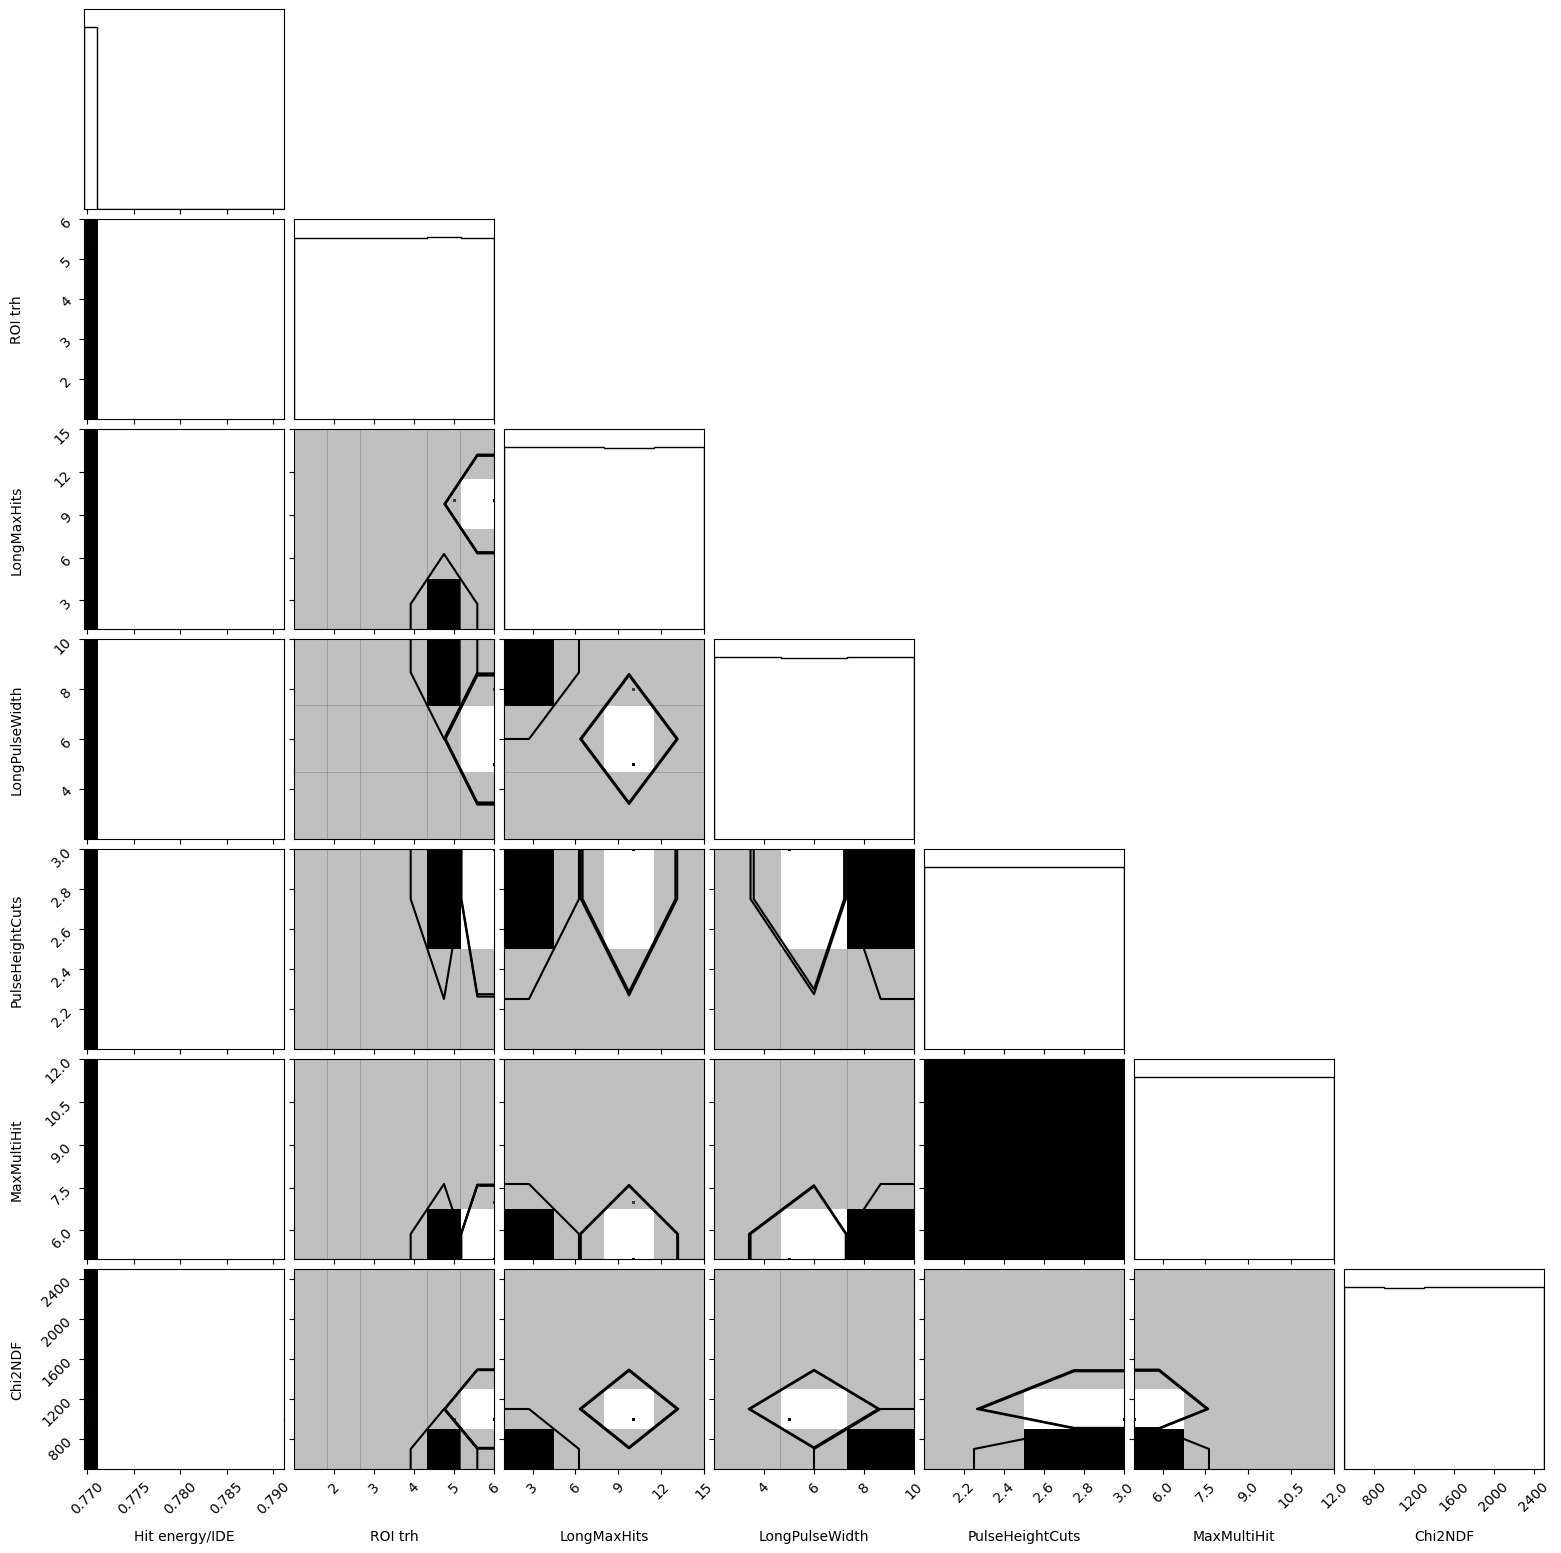

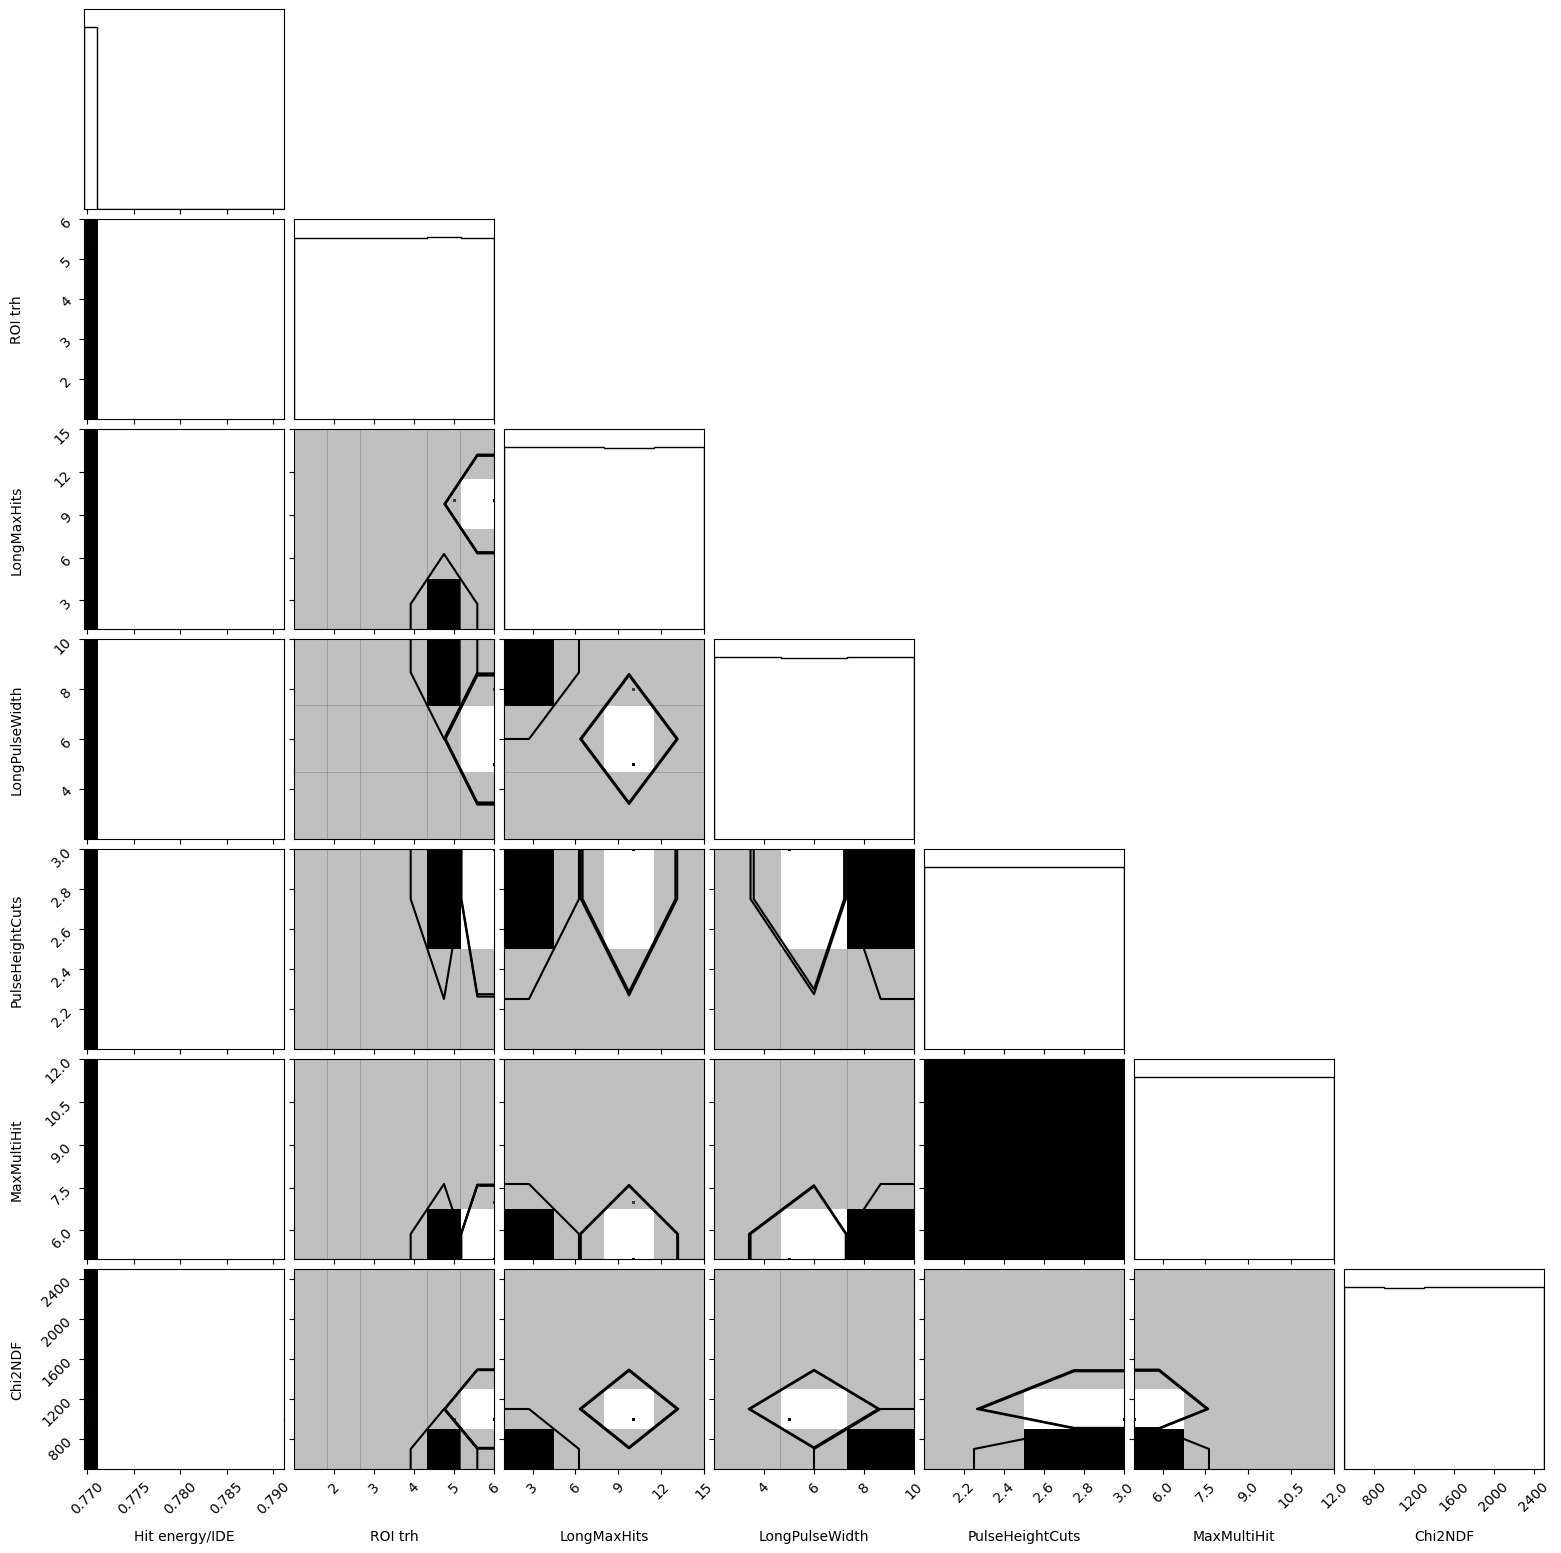

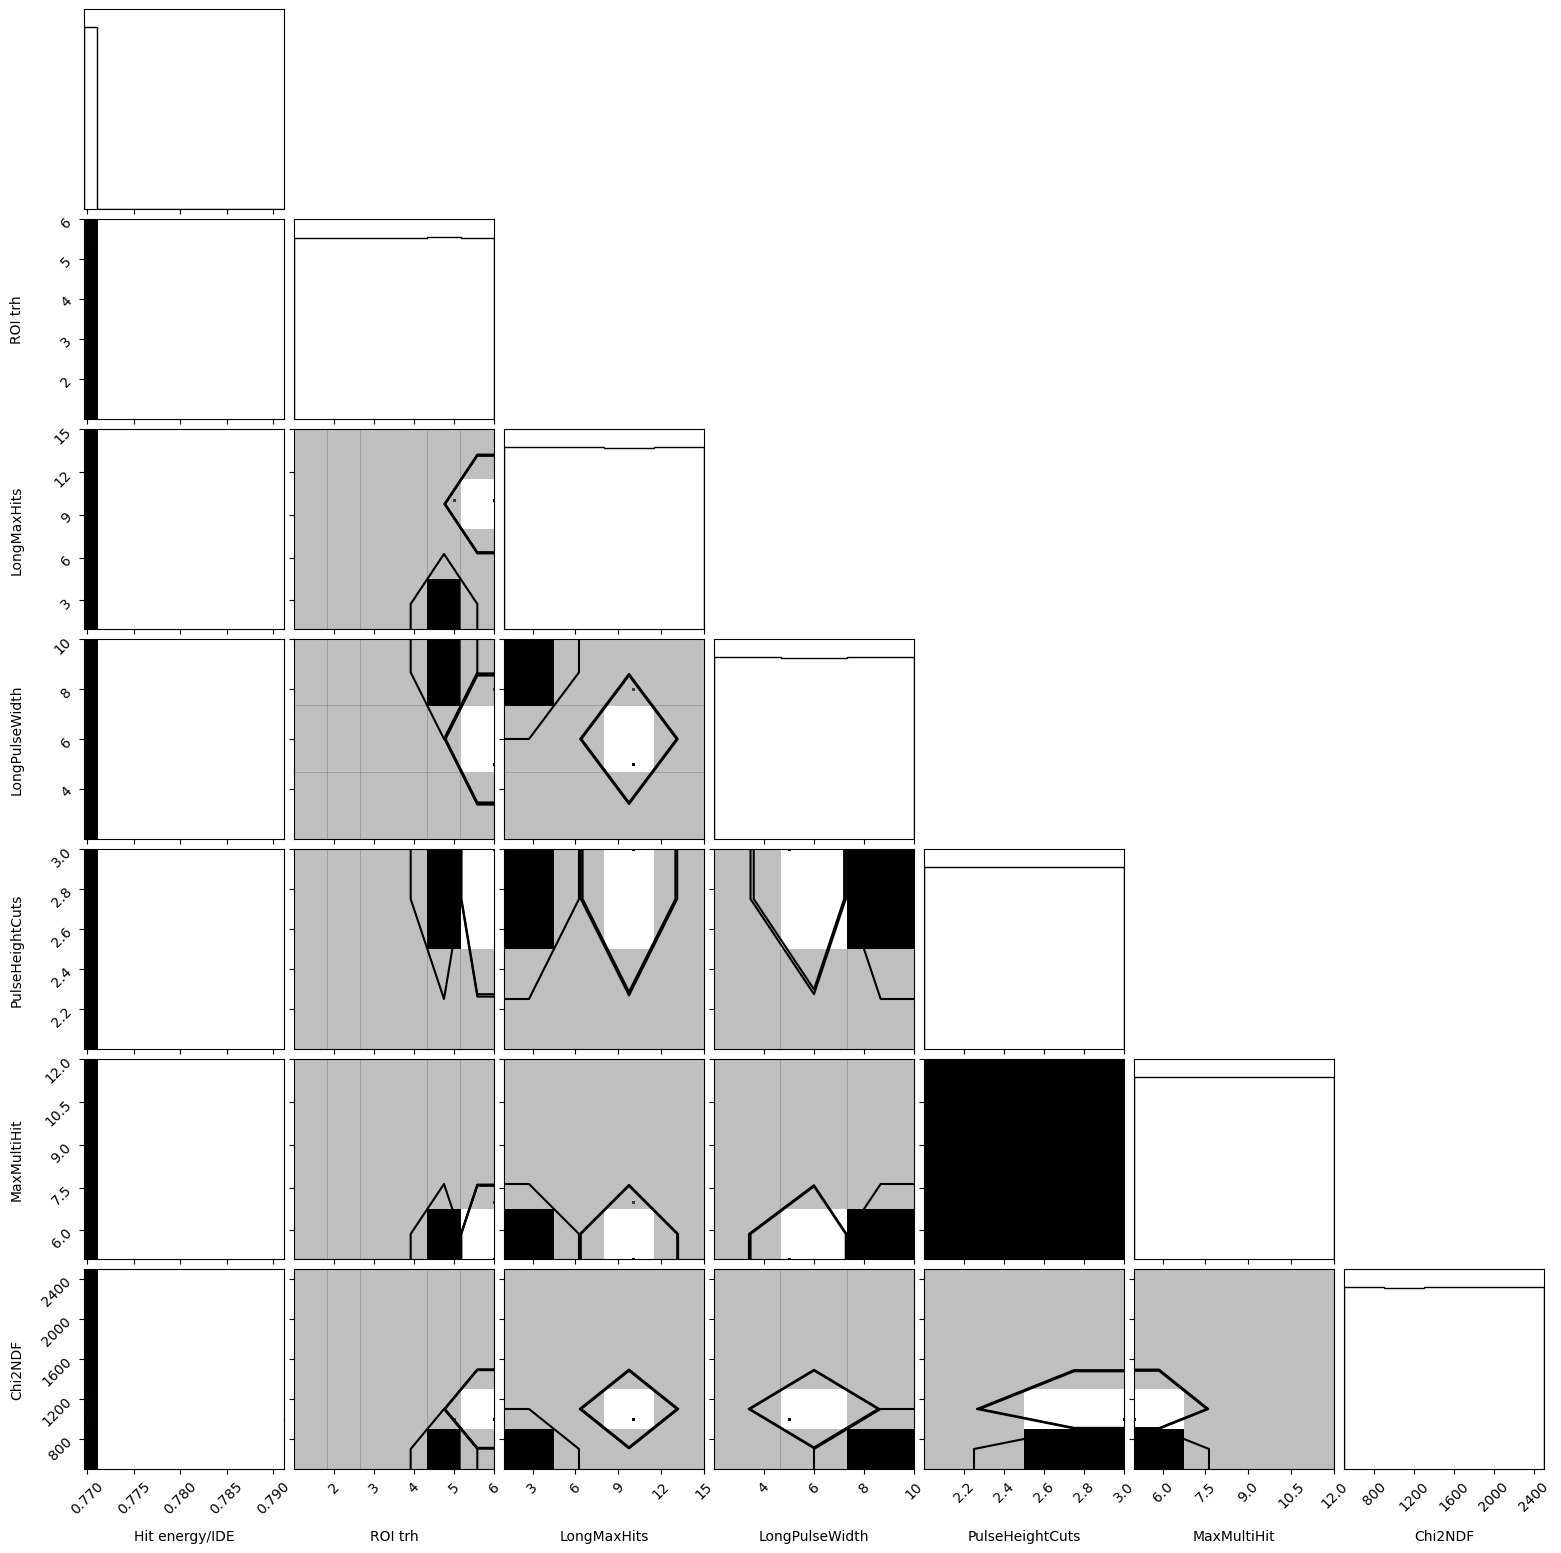

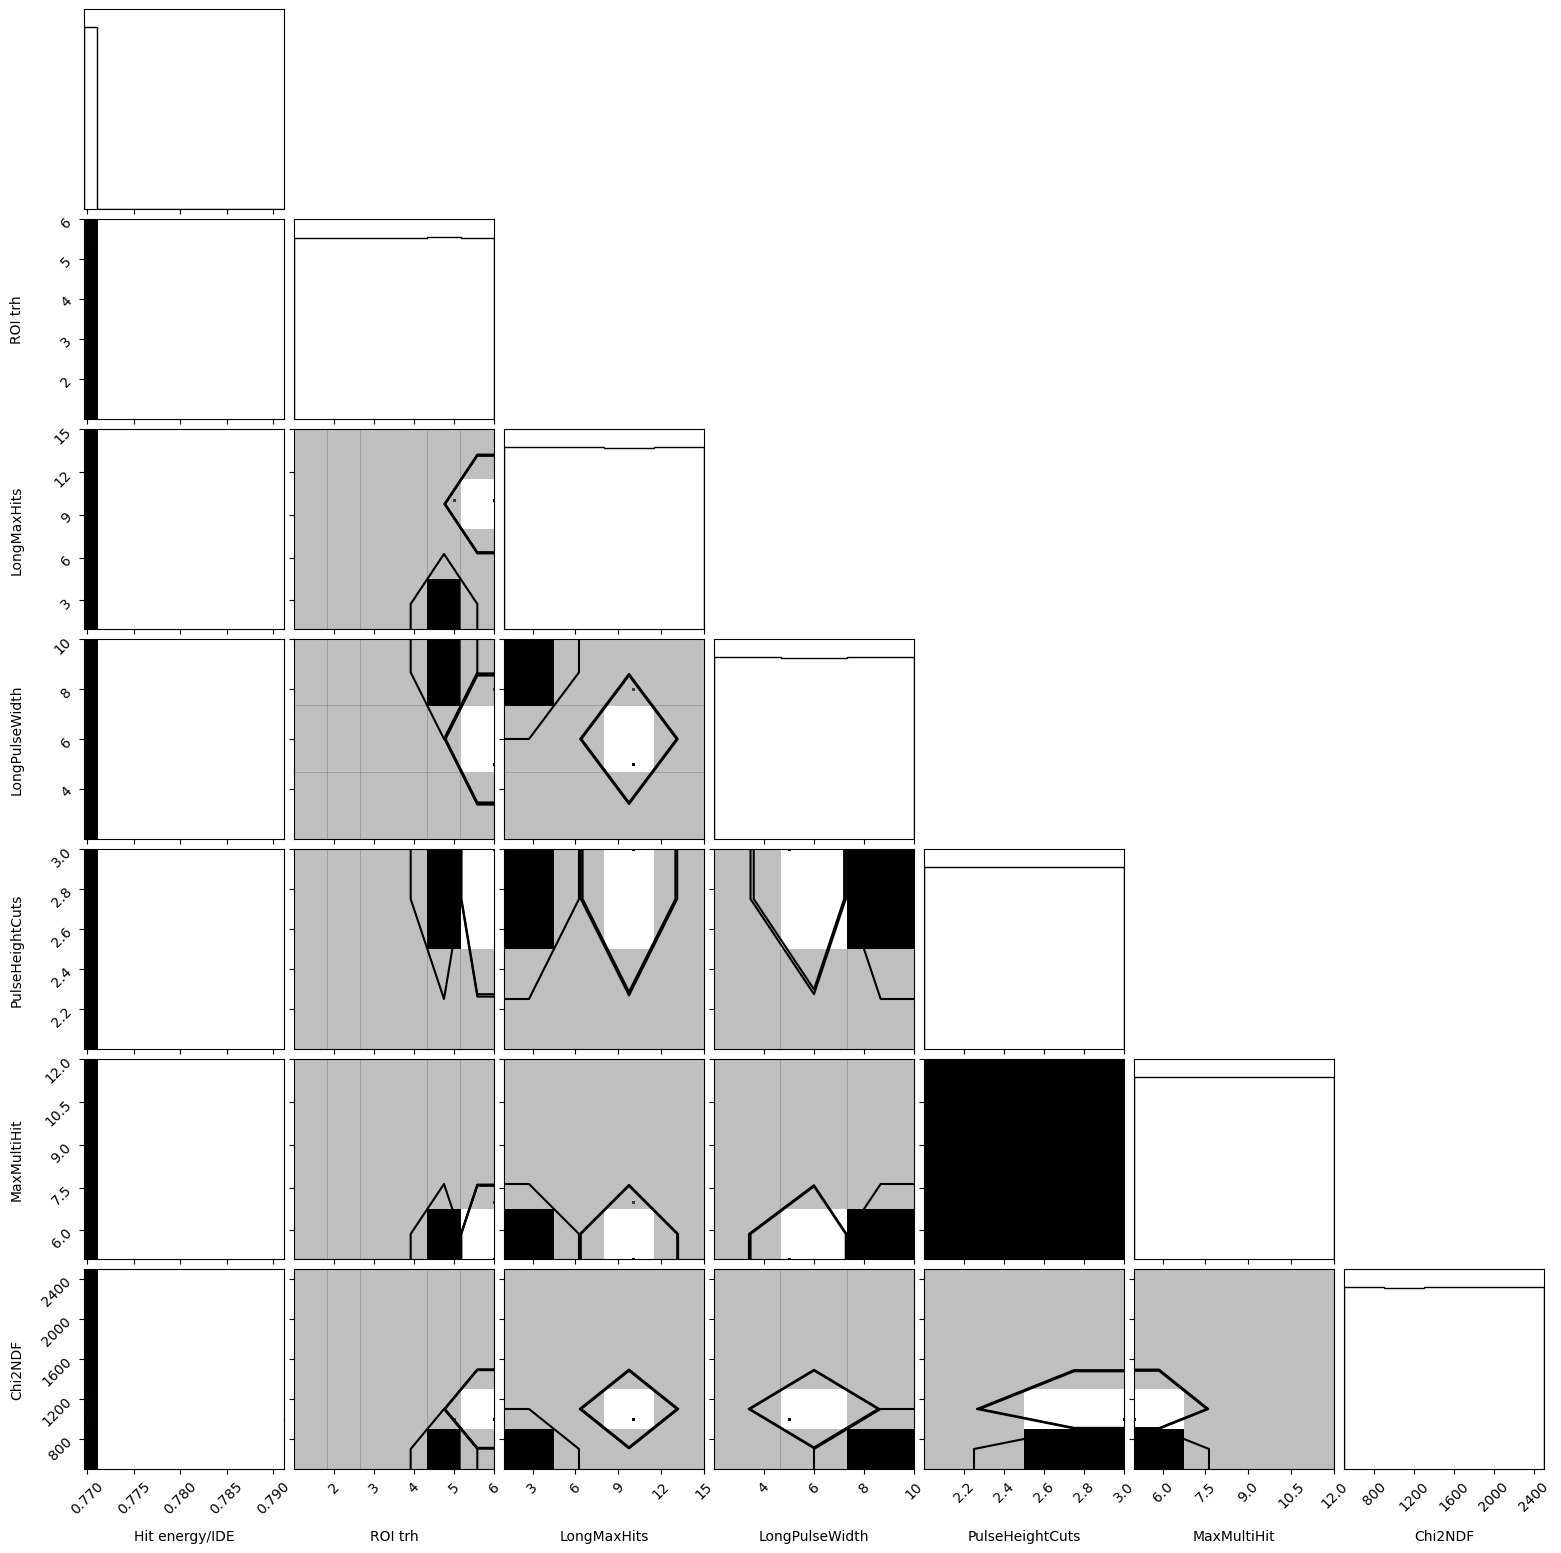

In [69]:
for plane in [0, 1, 2]:
    fig = plot_corner_byPlane(plane, compareTo='ratio_total{}')
    fig.savefig(f'ratio_total{plane}.png')
    for particle in ['ele', 'mu', 'p', 'pi']:
        fig = plot_corner_byPlane(plane, compareTo=f'ratio_{particle}{{}}')
        fig.savefig(f'ratio_{particle}{plane}.png')

FileNotFoundError: [Errno 2] No such file or directory: '/pnfs/icarus/scratch/users/msotgia/hitTuning/mc/gridThirdTest/outputs/00/hist_output_0.root'

In [72]:
data = uproot.open('tmp/testOneGalleryMetric/scorerTest.root:data')


In [81]:
data = data.arrays(library='ak')

In [87]:
for i in data['p0.hitFit']:
    print(i)

[0.0146, 0.0111, 0.0137, 0.00744, 0.0331, ..., 0.0211, 0.00978, 0.00157, 0.0197]
[0.0182, 0.0182, 0.0285, 0.0285, 0.0536, ..., 0.217, 0.321, 0.253, 0.0932]
[0.00632, 0.00601, 0.016, 0.00495, 0.0137, ..., 0.0251, 0.0442, 0.0442, 0.063]
[0.0421, 0.0386, 0.0386, 0.0291, 0.0291, ..., 0.00664, 0.00664, 0.0146, 0.0229]
[0.0265, 0.022, 0.0358, 0.015, 0.0428, ..., 0.0206, 0.0127, 0.0299, 0.0324]
[0.00793, 0.00804, 0.0142, 0.0162, 0.0162, ..., 0.0494, 0.0307, 0.0307, 0.018]
[0.000693, 0.0141, 0.0217, 0.0642, ..., 0.00315, 0.00081, 0.0269, 0.0266]
[0.0248, 0.0208, 0.0226, 0.00744, 0.00104, ..., 0.072, 0.0175, 0.0455, 0.0692]
[8.68, 8.68, 11.4, 11.4, 11.2, 8.58, ..., 0.486, 0.179, 0.179, 0.179, 0.0492]
[0.00493, 0.00641, 0.0112, 0.000554, 0.0116, ..., 0.00106, 0.00178, 0.37, 0.346]


In [88]:
data = uproot.open('tmp/testOneGalleryMetric/scorerTestSpine.root:data')

In [90]:
data = data.arrays(library='pd')

<Axes: >

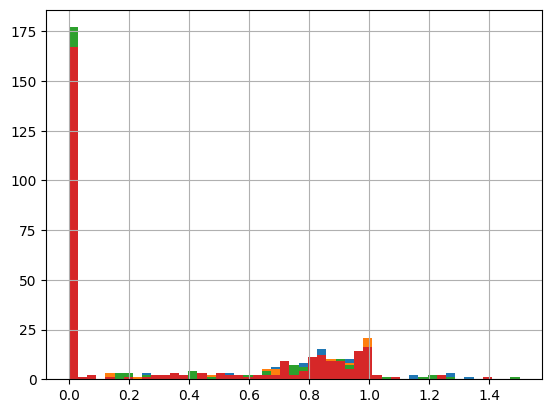

In [108]:
data[(data.neutralPions == 0) & (data.electrons == 0)].eventRatio.hist(bins=np.linspace(0,1.5))
data[(data.neutralPions == 0) & (data.electrons == 0)]['p0.planeRatio'].hist(bins=np.linspace(0,1.5))
data[(data.neutralPions == 0) & (data.electrons == 0)]['p1.planeRatio'].hist(bins=np.linspace(0,1.5))
data[(data.neutralPions == 0) & (data.electrons == 0)]['p2.planeRatio'].hist(bins=np.linspace(0,1.5))


In [109]:
connection = sql.connect('hitTuning_0.db')
data = pd.read_sql('SELECT * FROM runs', connection)